# RKD Face Verification: Evaluation v2

Restructured to match the updated experiment design: three models compared throughout — **Pretrained** (ResNet100+CosFace, Glint360K), **Fine-tuned** (EXP-3 style, ResNet100 fine-tuned on RKD all-media), and **Fusion** (Poh et al. CLIP+LoRA 3-component fusion).

**Data scope:** RQ1 (EXP1-5) is reported on the **full dataset** (27,337 portraits) for maximum statistical power, since the pretrained model saw no RKD training data. RQ2 (EXP6-10) and RQ3 (EXP11-14) — which involve fine-tuned/fusion models trained on the RKD train split — are evaluated on the **test split only** (5,136 portraits, 1,596 sitters) to avoid leakage, and independently recompute a test-split Pretrained baseline in each comparison cell so every "compared directly" claim is on matched data.

**Embedding sources:** Pretrained/Fine-tuned embeddings are the local extractions (`features_UNFINETUNED.pkl` / `features_exp3.pkl` / `features_exp4.pkl`) — verified to match the Swiss-team SURF re-extraction exactly on the full-dataset protocol (AUC 0.9383 both ways). Fusion embeddings come from the Swiss-team SURF pipeline (`D:/thesis/Swiss_team_rerun_embeddings/`), since no local fusion extraction exists.

**Fix vs. the previous notebook:** EXP10/EXP14 (fine-tuned/fusion artist-bias) now rebuild their pair sets from the test split only, rather than reusing full-dataset pairs that included train-split sitters — the earlier version had a leakage issue here.

## Setup

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from itertools import combinations as itr_combinations
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import normalize
from scipy.stats import mannwhitneyu
from matplotlib.patches import Patch

from src.evaluation.pairs import build_pairs, build_cross_medium_pairs
from src.evaluation.experiment import group_media

# src.evaluation.experiment -> src.evaluation.metrics forces matplotlib.use("Agg") on import,
# which silently overrides the inline backend set above. Re-assert it here so plots render.
%matplotlib inline

# Thesis-readable plot defaults — larger, consistent font sizes across every figure.
plt.rcParams.update({
    'font.size':        12,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.labelsize':   12,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'legend.fontsize':  10,
    'figure.titlesize': 15,
    'figure.titleweight': 'bold',
})

## Load data

In [2]:
df = pd.read_csv('training_set.csv')
df = group_media(df)

split_df     = pd.read_csv('train_test_split.csv')
test_sitters = set(split_df[split_df['split'] == 'test']['sitter_id'])
df_test      = df[df['sitter_id'].isin(test_sitters)].copy()

print(f'Full dataset: {len(df):,} portraits, {df["sitter_id"].nunique():,} sitters')
print(f'Test split:   {len(df_test):,} portraits, {df_test["sitter_id"].nunique():,} sitters')

lref_to_medium = df.set_index(df['lref'].astype(str))['medium_group'].to_dict()

Full dataset: 27,337 portraits, 7,981 sitters
Test split:   5,136 portraits, 1,596 sitters


## Load embeddings

In [3]:
def load_emb(path):
    feat_df = pd.read_pickle(path)
    feats   = np.stack(feat_df['feature'].values).squeeze(1)
    feats   = normalize(feats, norm='l2')
    return dict(zip(feat_df['filename'].astype(str), feats))

def load_npy_emb(path):
    """Swiss-team .npy embedding dict. Keys: 'data/paintings/{sitter_id}_{lref}.jpg'."""
    raw   = np.load(str(path), allow_pickle=True).item()
    keys  = list(raw.keys())
    vecs  = normalize(np.stack([raw[k].astype(np.float32) for k in keys]), norm='l2')
    lrefs = [Path(k).stem.split('_', 1)[1] for k in keys]
    return dict(zip(lrefs, vecs))

emb_pretrained = load_emb('features_UNFINETUNED.pkl')
emb_finetuned  = load_emb('features_exp3.pkl')           # EXP-3 style: all-media fine-tune
emb_oilonly    = load_emb('features_exp4.pkl')           # EXP9: oil-paintings-only fine-tune

EMB_DIR       = Path('D:/thesis/Swiss_team_rerun_embeddings')
emb_clip_base = load_npy_emb(EMB_DIR / 'clip_embeddings.npy')          # CLIP ViT-B/16, no LoRA
emb_clip_lora = load_npy_emb(EMB_DIR / 'clip_rkd_v2_embeddings.npy')   # CLIP ViT-B/16 + LoRA (RKD)
emb_fusion    = load_npy_emb(EMB_DIR / 'fusion_rkd_v2_embeddings.npy')

print(f'Pretrained: {len(emb_pretrained):,}  Fine-tuned: {len(emb_finetuned):,}  '
      f'Oil-only: {len(emb_oilonly):,}')
print(f'CLIP base: {len(emb_clip_base):,}  CLIP + LoRA: {len(emb_clip_lora):,}  Fusion: {len(emb_fusion):,}')

Pretrained: 27,337  Fine-tuned: 27,337  Oil-only: 27,337
CLIP base: 27,337  CLIP + LoRA: 27,337  Fusion: 27,337


## Comparison infrastructure

One fixed color per model, reused in every plot; a bootstrap-CI metrics function; a generic "compare N models across strata" builder that produces both a tidy long-format table (for grouped bar plots) and a wide table with delta columns (for reporting); and a running scorecard collecting every headline number for the summary at the end.

In [4]:
MODEL_COLORS = {
    'Pretrained':  '#4C72B0',
    'Fine-tuned':  '#DD8452',
    'Oil-only':    '#8172B2',
    'Fusion':      '#55A868',
}

SCORECARD = []

def log_scorecard(experiment, stratum, model, m):
    SCORECARD.append({
        'Experiment': experiment, 'Stratum': stratum, 'Model': model,
        'AUC': m['AUC'], 'Macro-AUC': m['macro_AUC'], 'EER': m['EER'],
        'TAR@1%': m['TAR@1%'], 'TAR@0.1%': m['TAR@0.1%'],
    })


def score_pairs(pairs, embeddings):
    scores, labels, sid_a, sid_b = [], [], [], []
    for lref_a, lref_b, label, sa, sb in pairs:
        ea = embeddings.get(str(lref_a))
        eb = embeddings.get(str(lref_b))
        if ea is None or eb is None:
            continue
        scores.append(float(np.dot(ea, eb)))
        labels.append(label)
        sid_a.append(sa)
        sid_b.append(sb)
    return (np.array(scores, dtype=np.float32), np.array(labels, dtype=np.int8),
            np.array(sid_a), np.array(sid_b))


def compute_metrics(scores, labels, sid_a, sid_b):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    auc_score = auc(fpr, tpr)

    fnr     = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer     = float((fpr[eer_idx] + fnr[eer_idx]) / 2)
    eer_thr = float(thresholds[eer_idx])

    valid_1   = np.where(fpr <= 0.01)[0]
    tar_1pct  = float(tpr[valid_1[-1]])  if len(valid_1)  else 0.0
    valid_01  = np.where(fpr <= 0.001)[0]
    tar_01pct = float(tpr[valid_01[-1]]) if len(valid_01) else 0.0

    gen_by_sid = defaultdict(list)
    imp_by_sid = defaultdict(list)
    for i, (sa, sb, lab) in enumerate(zip(sid_a, sid_b, labels)):
        if lab == 1:
            gen_by_sid[sa].append(i)
        else:
            imp_by_sid[sa].append(i)
            imp_by_sid[sb].append(i)

    per_sitter_aucs = []
    for sid, gen_idx in gen_by_sid.items():
        imp_idx = imp_by_sid.get(sid, [])
        if not gen_idx or not imp_idx:
            continue
        s = np.concatenate([scores[gen_idx], scores[imp_idx]])
        l = np.concatenate([np.ones(len(gen_idx)), np.zeros(len(imp_idx))])
        if len(np.unique(l)) < 2:
            continue
        fp, tp, _ = roc_curve(l, s, pos_label=1)
        per_sitter_aucs.append(auc(fp, tp))
    macro_auc = float(np.mean(per_sitter_aucs)) if per_sitter_aucs else None

    return {
        'AUC': round(float(auc_score), 4), 'macro_AUC': round(macro_auc, 4) if macro_auc is not None else None,
        'macro_n': len(per_sitter_aucs), 'EER': round(eer, 4), 'EER_thr': round(eer_thr, 4),
        'TAR@1%': round(tar_1pct, 4), 'TAR@0.1%': round(tar_01pct, 4),
        '_fpr': fpr, '_tpr': tpr, '_scores': scores, '_labels': labels,
    }


def compare_models_by_stratum(strata_pairs: dict, models: list):
    """strata_pairs: {label: pairs}. models: [(name, emb), ...]. Returns tidy long-format df."""
    rows = []
    for stratum, pairs in strata_pairs.items():
        for name, emb in models:
            sc, lb, sa, sb = score_pairs(pairs, emb)
            if len(sc) == 0 or len(np.unique(lb)) < 2:
                continue
            m = compute_metrics(sc, lb, sa, sb)
            rows.append({
                'Stratum': stratum, 'Model': name,
                'N genuine': int(lb.sum()), 'N impostor': int((lb == 0).sum()),
                'AUC': m['AUC'], 'EER': m['EER'],
                'TAR@1%': m['TAR@1%'], 'TAR@0.1%': m['TAR@0.1%'], 'Macro-AUC': m['macro_AUC'],
            })
    return pd.DataFrame(rows)


def wide_with_deltas(long_df, metric='AUC', baseline='Pretrained'):
    wide = long_df.pivot(index='Stratum', columns='Model', values=metric)
    for col in wide.columns:
        if col != baseline and baseline in wide.columns:
            wide[f'Δ {col}'] = wide[col] - wide[baseline]
    return wide


def plot_grouped_bars(long_df, metric='AUC', title='', ylim=None):
    strata = list(dict.fromkeys(long_df['Stratum']))       # preserve first-seen order
    models = list(dict.fromkeys(long_df['Model']))
    x = np.arange(len(strata))
    width = 0.8 / max(len(models), 1)
    fig, ax = plt.subplots(figsize=(max(10, len(strata) * 1.6), 6))
    for i, model in enumerate(models):
        sub = long_df[long_df['Model'] == model].set_index('Stratum').reindex(strata)
        vals = sub[metric].values.astype(float)
        ax.bar(x + (i - (len(models) - 1) / 2) * width, vals, width,
               label=model, color=MODEL_COLORS.get(model))
    ax.set_xticks(x)
    ax.set_xticklabels(strata, rotation=20, ha='right', fontsize=11)
    ax.set_ylabel(metric)
    ax.set_title(title)
    if ylim:
        ax.set_ylim(ylim)
    ax.legend(fontsize=11)
    ax.grid(axis='y', color='lightgrey', lw=0.7)
    plt.tight_layout()
    plt.show()


def plot_roc_panels(strata_pairs: dict, models: list, suptitle=''):
    """One subplot per model, each showing a combined ROC curve (one line per stratum)."""
    ncols = len(models)
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6.5), squeeze=False)
    axes = axes[0]
    colors = plt.cm.tab10.colors
    for ax, (name, emb) in zip(axes, models):
        for i, (stratum, pairs) in enumerate(strata_pairs.items()):
            sc, lb, sa, sb = score_pairs(pairs, emb)
            if len(sc) == 0 or len(np.unique(lb)) < 2:
                continue
            m = compute_metrics(sc, lb, sa, sb)
            c = colors[i % 10]
            ax.plot(m['_fpr'], m['_tpr'], color=c, lw=2,
                    label=f"{stratum}  AUC={m['AUC']:.4f}  EER={m['EER']:.4f}")
            ax.scatter([m['EER']], [1 - m['EER']], color=c, s=50, zorder=5)
        ax.set_xscale('log')
        ax.set_xlim([1e-4, 1])
        ax.set_ylim([0, 1])
        ax.grid(True, which='both', color='lightgrey', lw=0.7)
        ax.set_xlabel('FAR')
        ax.set_ylabel('TAR')
        ax.set_title(name)
        ax.legend(fontsize=10)
    plt.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_combined_roc(roc_by_model: dict, title='', eer_color=None):
    fig, ax = plt.subplots(figsize=(9, 7))
    for name, m in roc_by_model.items():
        c = MODEL_COLORS.get(name)
        ax.plot(m['_fpr'], m['_tpr'], color=c, lw=2,
                label=f"{name}  AUC={m['AUC']:.4f}  EER={m['EER']:.4f}")
        ax.scatter([m['EER']], [1 - m['EER']], color=(eer_color or c), s=60, zorder=5)
    ax.set_xscale('log')
    ax.set_xlim([1e-4, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, which='both', color='lightgrey', lw=0.7)
    ax.set_xlabel('FAR')
    ax.set_ylabel('TAR')
    ax.set_title(title)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

### Artist-bias pair builders

Parameterized by `df` so the exact same logic builds full-dataset pairs (RQ1) and test-split-only pairs (RQ2/RQ3), avoiding the duplication (and, in the test-split case, avoiding the leakage bug from the previous notebook version).

In [5]:
def build_artist_bias_pairs(df, min_sitters=5, cross_sample=200, seed=42):
    dfx = df[df['artist_name'] != 'Anoniem'].dropna(subset=['artist_id']).copy()
    dfx['artist_id'] = dfx['artist_id'].astype(int)
    artist_sitter_counts = dfx.groupby('artist_id')['sitter_id'].nunique()
    qualifying = set(artist_sitter_counts[artist_sitter_counts >= min_sitters].index)
    dfx = dfx[dfx['artist_id'].isin(qualifying)].copy()

    artist_portraits = {}
    for artist_id, grp in dfx.groupby('artist_id'):
        artist_portraits[int(artist_id)] = list(zip(
            grp['lref'].astype(str).tolist(), grp['sitter_id'].astype(str).tolist()))

    all_lrefs   = dfx['lref'].astype(str).values
    all_sitters = dfx['sitter_id'].astype(str).values
    all_artists = dfx['artist_id'].astype(int).values

    within_pairs = []
    for artist_id, portraits in artist_portraits.items():
        for (la, sa), (lb, sb) in itr_combinations(portraits, 2):
            if sa != sb:
                within_pairs.append((la, lb, artist_id, sa, sb))

    rng = np.random.default_rng(seed)
    cross_pairs = []
    for artist_id, portraits in artist_portraits.items():
        my_lrefs   = np.array([p[0] for p in portraits])
        my_sitters = np.array([p[1] for p in portraits])
        other_mask    = all_artists != artist_id
        other_lrefs   = all_lrefs[other_mask]
        other_sitters = all_sitters[other_mask]
        collected, attempts = 0, 0
        while collected < cross_sample and attempts < cross_sample * 20 and len(other_lrefs) > 0:
            ia = rng.integers(0, len(my_lrefs))
            ib = rng.integers(0, len(other_lrefs))
            if my_sitters[ia] != other_sitters[ib]:
                cross_pairs.append((my_lrefs[ia], other_lrefs[ib], artist_id, my_sitters[ia], other_sitters[ib]))
                collected += 1
            attempts += 1

    print(f"  Qualifying artists (>={min_sitters} sitters, excl. Anoniem): {len(qualifying):,}")
    print(f"  Portraits in filtered set: {len(dfx):,}")
    print(f"  Within-artist impostor pairs: {len(within_pairs):,}")
    print(f"  Cross-artist impostor pairs:  {len(cross_pairs):,}")

    return {'df5': dfx, 'qualifying': qualifying, 'artist_sitter_counts': artist_sitter_counts,
            'within_pairs': within_pairs, 'cross_pairs': cross_pairs}


def score_artist_pairs(pairs, embeddings):
    scores, artists = [], []
    for la, lb, artist_id, sa, sb in pairs:
        ea = embeddings.get(la)
        eb = embeddings.get(lb)
        if ea is None or eb is None:
            continue
        scores.append(float(np.dot(ea, eb)))
        artists.append(artist_id)
    return np.array(scores, dtype=np.float32), np.array(artists)


def artist_bias_summary(bias_data, embeddings):
    within_scores, within_artist_ids = score_artist_pairs(bias_data['within_pairs'], embeddings)
    cross_scores,  cross_artist_ids  = score_artist_pairs(bias_data['cross_pairs'],  embeddings)
    qualifying = bias_data['qualifying']
    within_means = {aid: float(np.mean(within_scores[within_artist_ids == aid]))
                     for aid in qualifying if (within_artist_ids == aid).sum() > 0}
    cross_means  = {aid: float(np.mean(cross_scores[cross_artist_ids == aid]))
                     for aid in qualifying if (cross_artist_ids == aid).sum() > 0}
    common = set(within_means) & set(cross_means)
    wm = np.array([within_means[a] for a in common])
    cm = np.array([cross_means[a] for a in common])
    stat, p = (mannwhitneyu(wm, cm, alternative='greater') if len(wm) > 0 and len(cm) > 0 else (None, None))
    return {'wm': wm, 'cm': cm, 'n_artists': len(common), 'stat': stat, 'p': p,
            'within_scores': within_scores, 'within_artist_ids': within_artist_ids,
            'within_means': within_means, 'cross_means': cross_means}


def build_medium_tagged_artist_pairs(df5, within_pairs, qualifying, min_pairs_med=3,
                                      cross_sample_med=200, seed=42):
    def tag_same_medium(pairs):
        tagged = []
        for row in pairs:
            med_a = lref_to_medium.get(str(row[0]))
            med_b = lref_to_medium.get(str(row[1]))
            if med_a is not None and med_a == med_b:
                tagged.append(row + (med_a,))
        return tagged

    within_tagged = tag_same_medium(within_pairs)

    medium_pool = {}
    for _, row in df5.iterrows():
        med = lref_to_medium.get(str(int(row['lref'])))
        if med is None:
            continue
        medium_pool.setdefault(med, {'lrefs': [], 'sitters': [], 'artists': []})
        medium_pool[med]['lrefs'].append(str(int(row['lref'])))
        medium_pool[med]['sitters'].append(str(int(row['sitter_id'])))
        medium_pool[med]['artists'].append(int(row['artist_id']))

    rng = np.random.default_rng(seed)
    cross_tagged_med = []
    for medium, pool in medium_pool.items():
        pool_lrefs   = np.array(pool['lrefs'])
        pool_sitters = np.array(pool['sitters'])
        pool_artists = np.array(pool['artists'])
        artists_in_med = set(pool_artists) & qualifying
        for aid in artists_in_med:
            my_mask = pool_artists == aid
            my_lrefs = pool_lrefs[my_mask]
            my_sitters = pool_sitters[my_mask]
            other_mask = pool_artists != aid
            other_lrefs = pool_lrefs[other_mask]
            other_sitters = pool_sitters[other_mask]
            if len(other_lrefs) == 0:
                continue
            collected, attempts = 0, 0
            while collected < cross_sample_med and attempts < cross_sample_med * 20:
                ia = rng.integers(0, len(my_lrefs))
                ib = rng.integers(0, len(other_lrefs))
                if my_sitters[ia] != other_sitters[ib]:
                    cross_tagged_med.append((my_lrefs[ia], other_lrefs[ib], aid,
                                              my_sitters[ia], other_sitters[ib], medium))
                    collected += 1
                attempts += 1
    return within_tagged, cross_tagged_med


def score_tagged_pairs(tagged, embeddings):
    scores, artists, mediums = [], [], []
    for row in tagged:
        ea = embeddings.get(str(row[0]))
        eb = embeddings.get(str(row[1]))
        if ea is None or eb is None:
            continue
        scores.append(float(np.dot(ea, eb)))
        artists.append(row[2])
        mediums.append(row[-1])
    return (np.array(scores, dtype=np.float32), np.array(artists), np.array(mediums, dtype=object))


def medium_bias_table(within_tagged, cross_tagged_med, embeddings, min_pairs_med=3):
    wt_scores, wt_artists, wt_mediums = score_tagged_pairs(within_tagged,    embeddings)
    ct_scores, ct_artists, ct_mediums = score_tagged_pairs(cross_tagged_med, embeddings)
    all_media = sorted(set(wt_mediums))
    rows, data = [], {}
    for medium in all_media:
        wm_mask, cm_mask = wt_mediums == medium, ct_mediums == medium
        w_s, w_a = wt_scores[wm_mask], wt_artists[wm_mask]
        c_s, c_a = ct_scores[cm_mask], ct_artists[cm_mask]
        w_means, c_means = [], []
        for aid in np.unique(w_a):
            wmask, cmask = w_a == aid, c_a == aid
            if wmask.sum() < min_pairs_med or cmask.sum() == 0:
                continue
            w_means.append(float(np.mean(w_s[wmask])))
            c_means.append(float(np.mean(c_s[cmask])))
        if len(w_means) < 2:
            continue
        wm, cm = np.array(w_means), np.array(c_means)
        stat, p = mannwhitneyu(wm, cm, alternative='greater')
        rows.append({'Medium': medium, 'N artists': len(wm),
                      'Mean within': round(float(np.mean(wm)), 4), 'Mean cross': round(float(np.mean(cm)), 4),
                      'Mean delta': round(float(np.mean(wm - cm)), 4), 'p-value': round(p, 4)})
        data[medium] = {'wm': wm, 'cm': cm}
    return pd.DataFrame(rows), data


def build_artist_genuine_pairs(df):
    dfx = df.dropna(subset=['artist_id']).copy()
    dfx['artist_id'] = dfx['artist_id'].astype(int)
    dfx['sitter_id'] = dfx['sitter_id'].astype(int)
    within_genuine = []
    for (artist_id, sitter_id), grp in dfx.groupby(['artist_id', 'sitter_id']):
        lrefs = grp['lref'].astype(str).tolist()
        if len(lrefs) < 2:
            continue
        sid = str(sitter_id)
        for la, lb in itr_combinations(lrefs, 2):
            within_genuine.append((la, lb, 1, sid, sid))
    cross_genuine = []
    for sitter_id, grp in dfx.groupby('sitter_id'):
        if grp['artist_id'].nunique() < 2:
            continue
        portraits = list(zip(grp['lref'].astype(str).tolist(), grp['artist_id'].tolist()))
        sid = str(sitter_id)
        for (la, aa), (lb, ab) in itr_combinations(portraits, 2):
            if aa != ab:
                cross_genuine.append((la, lb, 1, sid, sid))
    return within_genuine, cross_genuine

---
# RQ1: ResNet100 + CosFace (Glint360K weights)

Evaluated on the **full dataset** (27,337 portraits) — the pretrained model saw no RKD training data, so no held-out split is required for it to be evaluated fairly on its own. This section establishes the baseline that EXP6-14 will be compared against (recomputed on the test split within each comparison cell, for fairness to the fine-tuned/fusion models).

### EXP1: Overall evaluation

The pretrained model evaluated on the full RKD dataset, no fine-tuning.

Pairs built — genuine: 168,546  impostor: 1,685,460  ratio: 1:10
Genuine:    168,546  |  Impostor: 1,685,460
AUC:        0.9383
Macro-AUC:  0.9513  (over 7,981 sitters)
EER:        0.1363  (threshold = 0.1664)
TAR@1%:     0.5944
TAR@0.1%:   0.3836


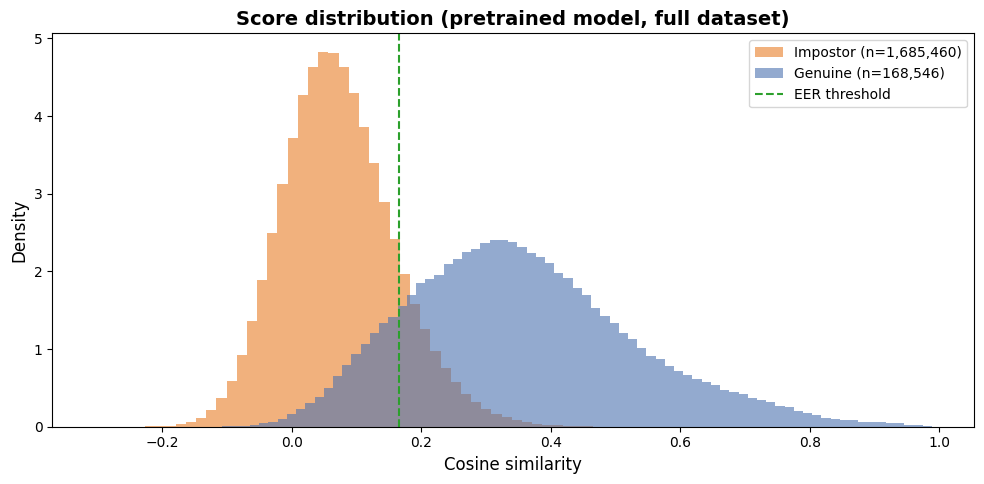

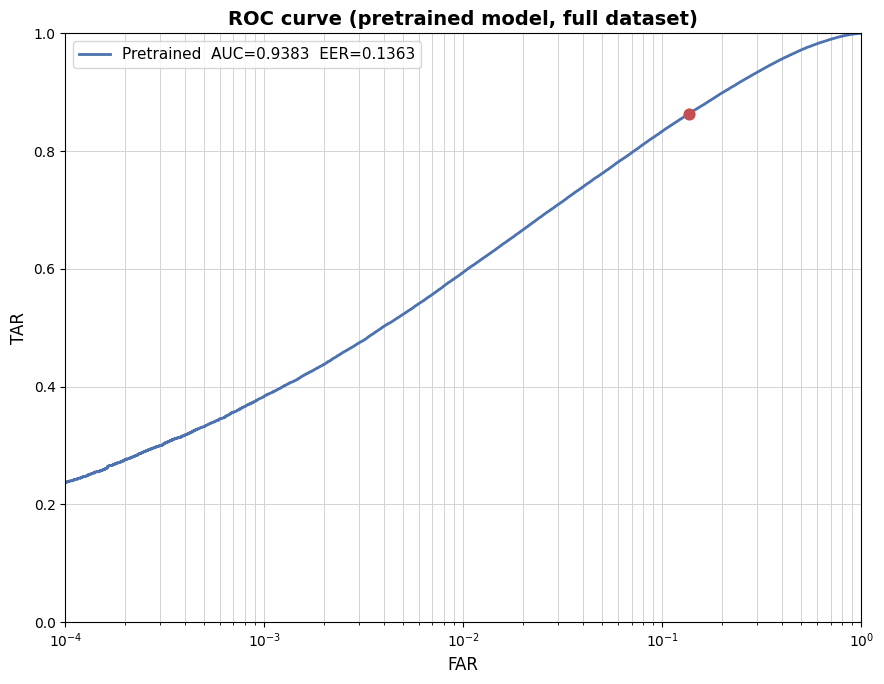

In [6]:
pairs_exp1                    = build_pairs(df, impostor_ratio=10, seed=42)
scores, labels, sid_a, sid_b  = score_pairs(pairs_exp1, emb_pretrained)
m_exp1                        = compute_metrics(scores, labels, sid_a, sid_b)

print(f'Genuine:    {labels.sum():,}  |  Impostor: {(labels==0).sum():,}')
print(f'AUC:        {m_exp1["AUC"]}')
print(f'Macro-AUC:  {m_exp1["macro_AUC"]}  (over {m_exp1["macro_n"]:,} sitters)')
print(f'EER:        {m_exp1["EER"]}  (threshold = {m_exp1["EER_thr"]})')
print(f'TAR@1%:     {m_exp1["TAR@1%"]}')
print(f'TAR@0.1%:   {m_exp1["TAR@0.1%"]}')
log_scorecard('EXP1', 'Full dataset', 'Pretrained', m_exp1)

genuine  = scores[labels == 1]
impostor = scores[labels == 0]
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(impostor, bins=80, density=True, alpha=0.6, color='#E87D27', label=f'Impostor (n={len(impostor):,})')
ax.hist(genuine,  bins=80, density=True, alpha=0.6, color=MODEL_COLORS['Pretrained'], label=f'Genuine (n={len(genuine):,})')
ax.axvline(m_exp1['EER_thr'], color='#2CA02C', linestyle='--', lw=1.5, label='EER threshold')
ax.set_xlabel('Cosine similarity'); ax.set_ylabel('Density')
ax.set_title('Score distribution (pretrained model, full dataset)')
ax.legend(); plt.tight_layout(); plt.show()

plot_combined_roc({'Pretrained': m_exp1}, title='ROC curve (pretrained model, full dataset)', eer_color='#C44E52')

### RQ1a: How does performance vary between artistic media?

### EXP2: Stratified evaluation by medium

The pretrained model evaluated separately per medium group. Metrics reported with bootstrap 95% confidence intervals.

Pairs built — genuine: 35,044  impostor: 350,440  ratio: 1:10
Pairs built — genuine: 12,190  impostor: 121,900  ratio: 1:10
Pairs built — genuine: 24,670  impostor: 246,700  ratio: 1:10
Pairs built — genuine: 3,061  impostor: 30,610  ratio: 1:10
Pairs built — genuine: 513  impostor: 5,130  ratio: 1:10
Pairs built — genuine: 593  impostor: 5,930  ratio: 1:10
Pairs built — genuine: 43  impostor: 430  ratio: 1:10


,Medium,Portraits,Sitters,AUC,Macro-AUC,EER,EER threshold,TAR@1%,TAR@0.1%
0,Oil paintings,"9,613","4,416",0.9544,0.9579,0.1144,0.2055,0.6551,0.4474
1,Photographs,"7,557","2,978",0.9790,0.9724,0.0613,0.1986,0.8916,0.8201
2,Prints,"4,698","1,547",0.9121,0.9615,0.1669,0.2090,0.4916,0.2909
3,Drawings,"3,644","2,311",0.9273,0.9254,0.1484,0.1788,0.5449,0.3290
4,Portrait miniatures,"1,036",769,0.8981,0.9333,0.1890,0.2219,0.5010,0.3372
5,Sculpture,491,302,0.8484,0.9085,0.2322,0.1680,0.3153,0.1703
6,Other,298,260,0.8127,0.7940,0.2581,0.2258,0.0000,0.0000


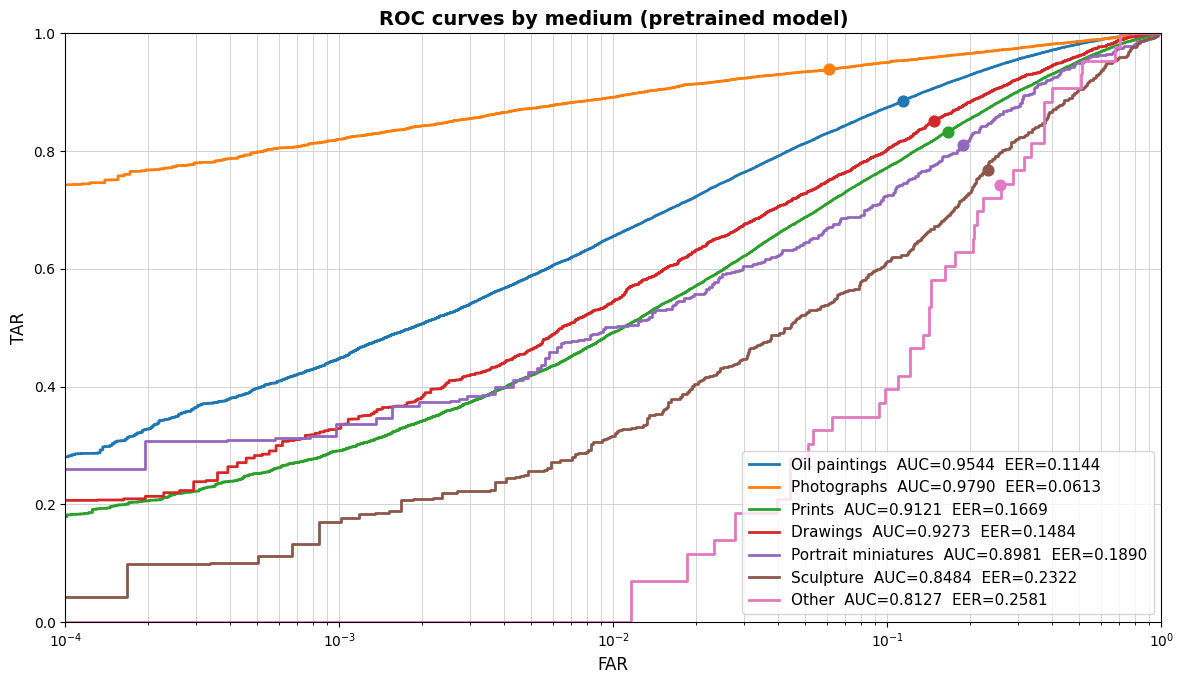

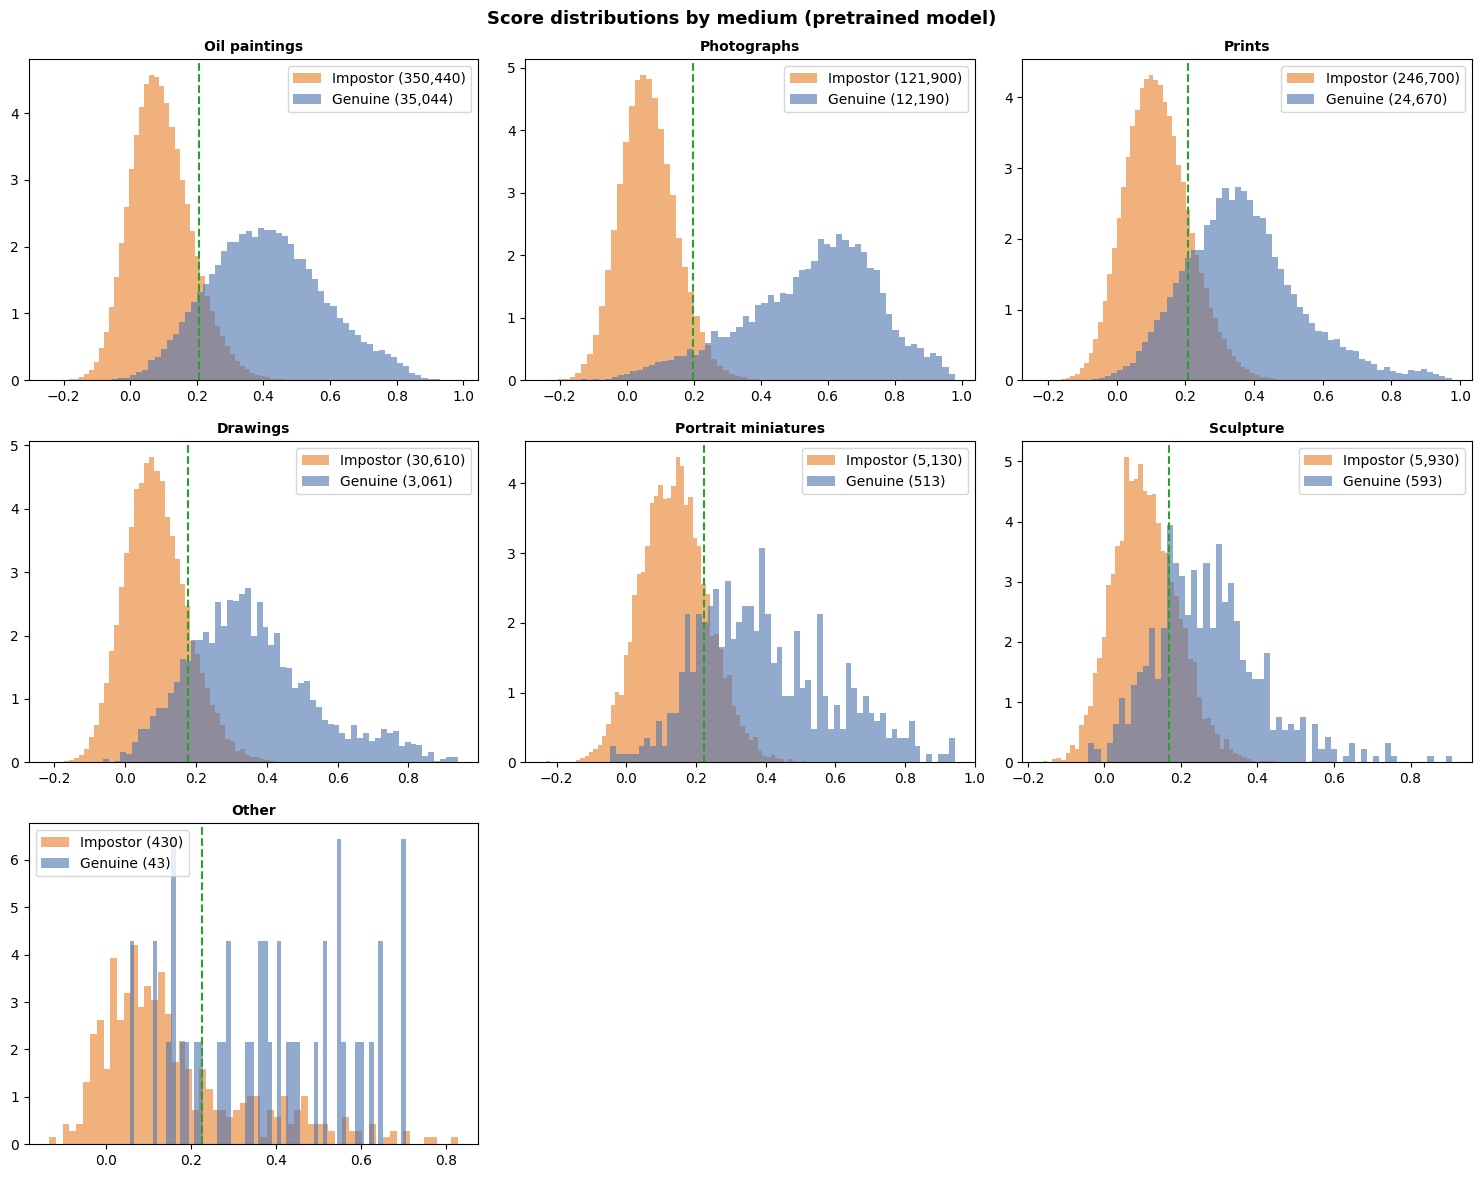

In [7]:
media_exp2 = (df.groupby('medium_group')['lref'].count()
                .sort_values(ascending=False).index.tolist())

rows_exp2, roc_entries_exp2 = [], []
for medium in media_exp2:
    subset = df[df['medium_group'] == medium]
    if subset['sitter_id'].nunique() < 2:
        continue
    pairs = build_pairs(subset, impostor_ratio=10, seed=42)
    sc, lb, sa, sb = score_pairs(pairs, emb_pretrained)
    m = compute_metrics(sc, lb, sa, sb)
    log_scorecard('EXP2', medium, 'Pretrained', m)
    rows_exp2.append({
        'Medium': medium, 'Portraits': len(subset), 'Sitters': subset['sitter_id'].nunique(),
        'AUC': m['AUC'], 'Macro-AUC': m['macro_AUC'], 'EER': m['EER'], 'EER threshold': m['EER_thr'],
        'TAR@1%': m['TAR@1%'], 'TAR@0.1%': m['TAR@0.1%'],
    })
    roc_entries_exp2.append({'label': medium, 'fpr': m['_fpr'], 'tpr': m['_tpr'],
                              'auc': m['AUC'], 'eer': m['EER'],
                              'scores': sc, 'labels': lb, 'eer_thr': m['EER_thr']})

display(pd.DataFrame(rows_exp2).style.format({
    'AUC':'{:.4f}', 'Macro-AUC':'{:.4f}', 'EER':'{:.4f}', 'EER threshold':'{:.4f}',
    'TAR@1%':'{:.4f}', 'TAR@0.1%':'{:.4f}', 'Portraits':'{:,}', 'Sitters':'{:,}',
}))

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(12, 7))
for i, e in enumerate(roc_entries_exp2):
    c = colors[i % 10]
    ax.plot(e['fpr'], e['tpr'], color=c, lw=2, label=f"{e['label']}  AUC={e['auc']:.4f}  EER={e['eer']:.4f}")
    ax.scatter([e['eer']], [1 - e['eer']], color=c, s=60, zorder=5)
ax.set_xscale('log'); ax.set_xlim([1e-4, 1]); ax.set_ylim([0, 1])
ax.grid(True, which='both', color='lightgrey', lw=0.7)
ax.set_xlabel('FAR'); ax.set_ylabel('TAR')
ax.set_title('ROC curves by medium (pretrained model)')
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

n = len(roc_entries_exp2)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()
for i, e in enumerate(roc_entries_exp2):
    ax  = axes[i]
    gen = e['scores'][e['labels'] == 1]
    imp = e['scores'][e['labels'] == 0]
    ax.hist(imp, bins=60, density=True, alpha=0.6, color='#E87D27', label=f'Impostor ({len(imp):,})')
    ax.hist(gen, bins=60, density=True, alpha=0.6, color=MODEL_COLORS['Pretrained'], label=f'Genuine ({len(gen):,})')
    ax.axvline(e['eer_thr'], color='#2CA02C', linestyle='--', lw=1.5)
    ax.set_title(e['label'], fontsize=10)
    ax.legend(fontsize=10)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Score distributions by medium (pretrained model)', fontsize=13)
plt.tight_layout(); plt.show()

### EXP3: Cross-medium genuine pairs

Sitters appearing in more than one of the four main medium groups (Oil paintings, Photographs, Prints, Drawings) are evaluated on cross-medium genuine pairs, testing whether the model recognizes the same person across media.

Sitters appearing in 2+ of the 4 main medium groups: 2,916
  Cross-medium (Oil paintings × Prints) — shared sitters: 937  genuine: 43,234  impostor: 432,340
  Cross-medium (Oil paintings × Drawings) — shared sitters: 1,357  genuine: 8,894  impostor: 88,940
  Cross-medium (Oil paintings × Photographs) — shared sitters: 614  genuine: 5,315  impostor: 53,150
  Cross-medium (Drawings × Prints) — shared sitters: 448  genuine: 4,961  impostor: 49,610
  Cross-medium (Photographs × Prints) — shared sitters: 152  genuine: 3,496  impostor: 34,960
  Cross-medium (Drawings × Photographs) — shared sitters: 362  genuine: 2,118  impostor: 21,180


,Combination,Genuine,Impostor,AUC,Macro-AUC,EER,EER threshold,TAR@1%,TAR@0.1%
0,Oil paintings × Prints,"43,234","432,340",0.9295,0.9397,0.1465,0.1821,0.5360,0.2980
1,Oil paintings × Drawings,"8,894","88,940",0.8941,0.9181,0.1903,0.1574,0.4530,0.2702
2,Oil paintings × Photographs,"5,315","53,150",0.9546,0.9529,0.1136,0.1433,0.7029,0.5281
3,Drawings × Prints,"4,961","49,610",0.8837,0.9323,0.2026,0.1592,0.4080,0.2373
4,Photographs × Prints,"3,496","34,960",0.9546,0.9599,0.1104,0.1431,0.7100,0.5503
5,Drawings × Photographs,"2,118","21,180",0.9304,0.9250,0.1501,0.1310,0.5770,0.3952


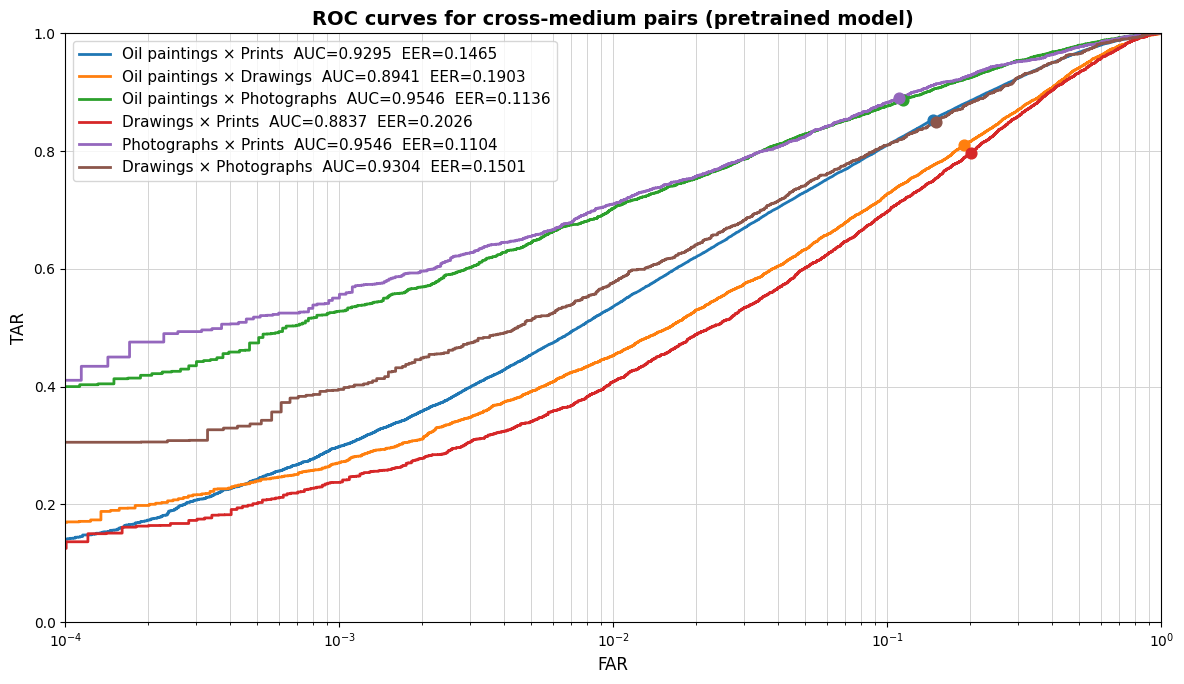

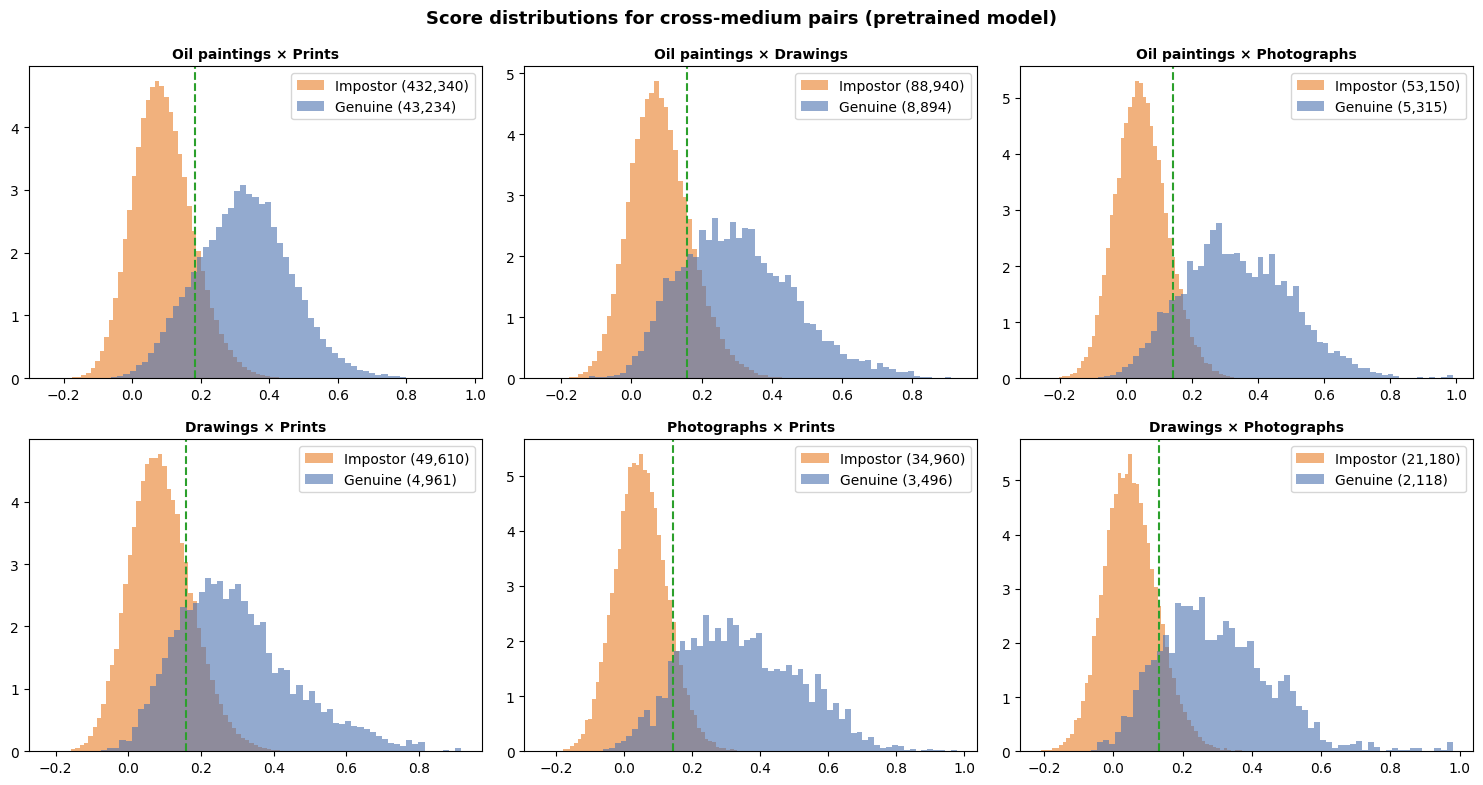

In [8]:
CROSS_MEDIA = ['Oil paintings', 'Photographs', 'Prints', 'Drawings']
combos_exp3 = [('Oil paintings','Prints'), ('Oil paintings','Drawings'), ('Oil paintings','Photographs'),
               ('Drawings','Prints'), ('Photographs','Prints'), ('Drawings','Photographs')]

# How many sitters appear in 2+ of the four main medium groups
sitter_media = df[df['medium_group'].isin(CROSS_MEDIA)].groupby('sitter_id')['medium_group'].nunique()
n_multi_medium_sitters = int((sitter_media >= 2).sum())
print(f'Sitters appearing in 2+ of the 4 main medium groups: {n_multi_medium_sitters:,}')

rows_exp3, roc_entries_exp3 = [], []
for a, b in combos_exp3:
    pairs = build_cross_medium_pairs(df, 'medium_group', a, b, impostor_ratio=10, seed=42)
    if not pairs:
        continue
    sc, lb, sa, sb = score_pairs(pairs, emb_pretrained)
    m = compute_metrics(sc, lb, sa, sb)
    label = f'{a} × {b}'
    log_scorecard('EXP3', label, 'Pretrained', m)
    rows_exp3.append({
        'Combination': label, 'Genuine': int(lb.sum()), 'Impostor': int((lb == 0).sum()),
        'AUC': m['AUC'], 'Macro-AUC': m['macro_AUC'], 'EER': m['EER'], 'EER threshold': m['EER_thr'],
        'TAR@1%': m['TAR@1%'], 'TAR@0.1%': m['TAR@0.1%'],
    })
    roc_entries_exp3.append({'label': label, 'fpr': m['_fpr'], 'tpr': m['_tpr'],
                              'auc': m['AUC'], 'eer': m['EER'],
                              'scores': sc, 'labels': lb, 'eer_thr': m['EER_thr']})

display(pd.DataFrame(rows_exp3).style.format({
    'AUC':'{:.4f}', 'Macro-AUC':'{:.4f}', 'EER':'{:.4f}', 'EER threshold':'{:.4f}',
    'TAR@1%':'{:.4f}', 'TAR@0.1%':'{:.4f}', 'Genuine':'{:,}', 'Impostor':'{:,}',
}))

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(12, 7))
for i, e in enumerate(roc_entries_exp3):
    c = colors[i % 10]
    ax.plot(e['fpr'], e['tpr'], color=c, lw=2, label=f"{e['label']}  AUC={e['auc']:.4f}  EER={e['eer']:.4f}")
    ax.scatter([e['eer']], [1 - e['eer']], color=c, s=60, zorder=5)
ax.set_xscale('log'); ax.set_xlim([1e-4, 1]); ax.set_ylim([0, 1])
ax.grid(True, which='both', color='lightgrey', lw=0.7)
ax.set_xlabel('FAR'); ax.set_ylabel('TAR')
ax.set_title('ROC curves for cross-medium pairs (pretrained model)')
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

n = len(roc_entries_exp3)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()
for i, e in enumerate(roc_entries_exp3):
    ax  = axes[i]
    gen = e['scores'][e['labels'] == 1]
    imp = e['scores'][e['labels'] == 0]
    ax.hist(imp, bins=60, density=True, alpha=0.6, color='#E87D27', label=f'Impostor ({len(imp):,})')
    ax.hist(gen, bins=60, density=True, alpha=0.6, color=MODEL_COLORS['Pretrained'], label=f'Genuine ({len(gen):,})')
    ax.axvline(e['eer_thr'], color='#2CA02C', linestyle='--', lw=1.5)
    ax.set_title(e['label'], fontsize=10)
    ax.legend(fontsize=10)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Score distributions for cross-medium pairs (pretrained model)', fontsize=13)
plt.tight_layout(); plt.show()

### RQ1b: To what extent are similarity scores inflated by artist or workshop style rather than identity?

| | Same artist (within-artist) | Different artist (cross-artist) |
|---|---|---|
| **Genuine (same sitter)** | Same person, same style. Should score high. | Same person, different style. Should score high, but harder. |
| **Impostor (different sitter)** | Different people, same artist/style. Should score low — if not, artist bias. | Baseline impostor case. Should score low. |

### EXP4: Artist bias detection

For every qualifying artist (≥5 sitters, excluding "Anoniem"), the mean similarity of within-artist impostor pairs is compared to cross-artist impostor pairs.

- **EXP4a**: within-artist vs. cross-artist impostor score distributions, overall.
- **EXP4b**: the same, stratified by medium.

  Qualifying artists (>=5 sitters, excl. Anoniem): 658
  Portraits in filtered set: 15,645
  Within-artist impostor pairs: 674,337
  Cross-artist impostor pairs:  131,600


,Group,N artists,Mean,Median,Std
0,Within-artist impostors,658,0.1528,0.1459,0.0720
1,Cross-artist impostors,658,0.0734,0.0755,0.0192



Mann-Whitney U (within > cross): U=372221.0, p=0.0000
--> Within-artist impostor scores are significantly higher (artist bias detected)


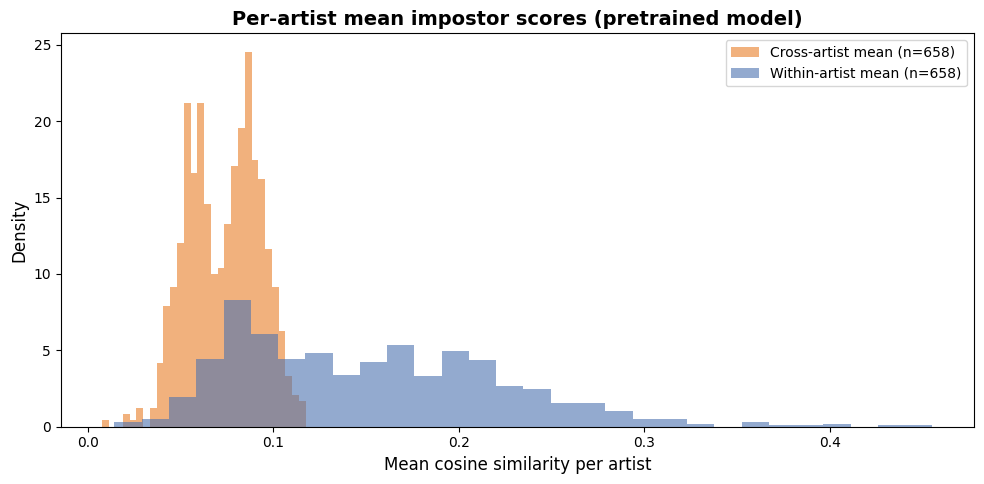

In [9]:
bias_exp4 = build_artist_bias_pairs(df, min_sitters=5, cross_sample=200, seed=42)
res_exp4a = artist_bias_summary(bias_exp4, emb_pretrained)

display(pd.DataFrame({
    'Group':     ['Within-artist impostors', 'Cross-artist impostors'],
    'N artists': [len(res_exp4a['wm']), len(res_exp4a['cm'])],
    'Mean':      [round(float(np.mean(res_exp4a['wm'])),4), round(float(np.mean(res_exp4a['cm'])),4)],
    'Median':    [round(float(np.median(res_exp4a['wm'])),4), round(float(np.median(res_exp4a['cm'])),4)],
    'Std':       [round(float(np.std(res_exp4a['wm'])),4), round(float(np.std(res_exp4a['cm'])),4)],
}))
print(f"\nMann-Whitney U (within > cross): U={res_exp4a['stat']:.1f}, p={res_exp4a['p']:.4f}")
print('--> Within-artist impostor scores are significantly higher (artist bias detected)'
      if res_exp4a['p'] < 0.05 else '--> No significant difference')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(res_exp4a['cm'], bins=30, density=True, alpha=0.6, color='#E87D27', label=f"Cross-artist mean (n={len(res_exp4a['cm'])})")
ax.hist(res_exp4a['wm'], bins=30, density=True, alpha=0.6, color=MODEL_COLORS['Pretrained'], label=f"Within-artist mean (n={len(res_exp4a['wm'])})")
ax.set_xlabel('Mean cosine similarity per artist'); ax.set_ylabel('Density')
ax.set_title('Per-artist mean impostor scores (pretrained model)')
ax.legend(); plt.tight_layout(); plt.show()

,Medium,N artists,Mean within,Mean cross,Mean delta,p-value
0,Drawings,144,0.1765,0.0882,+0.0883,0.0000
1,Oil paintings,294,0.1737,0.0912,+0.0825,0.0000
2,Other,4,0.2821,0.1116,+0.1705,0.1000
3,Photographs,159,0.0825,0.0656,+0.0169,0.0000
4,Portrait miniatures,29,0.2277,0.1407,+0.0870,0.0000
5,Prints,154,0.1810,0.1160,+0.0650,0.0000
6,Sculpture,14,0.1951,0.1090,+0.0861,0.0001


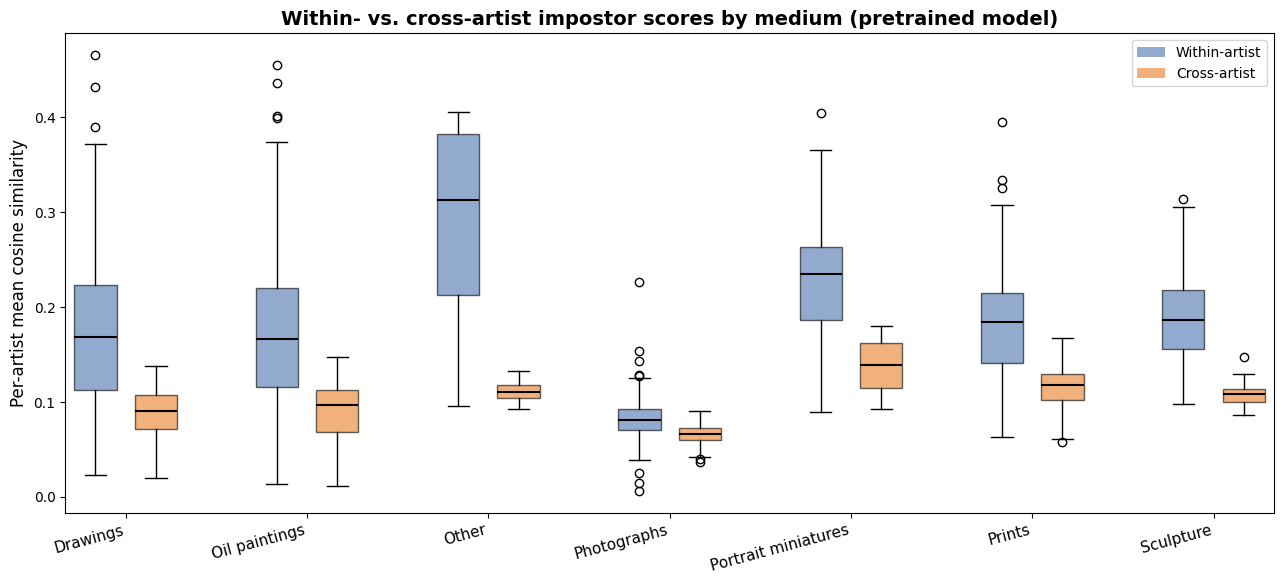

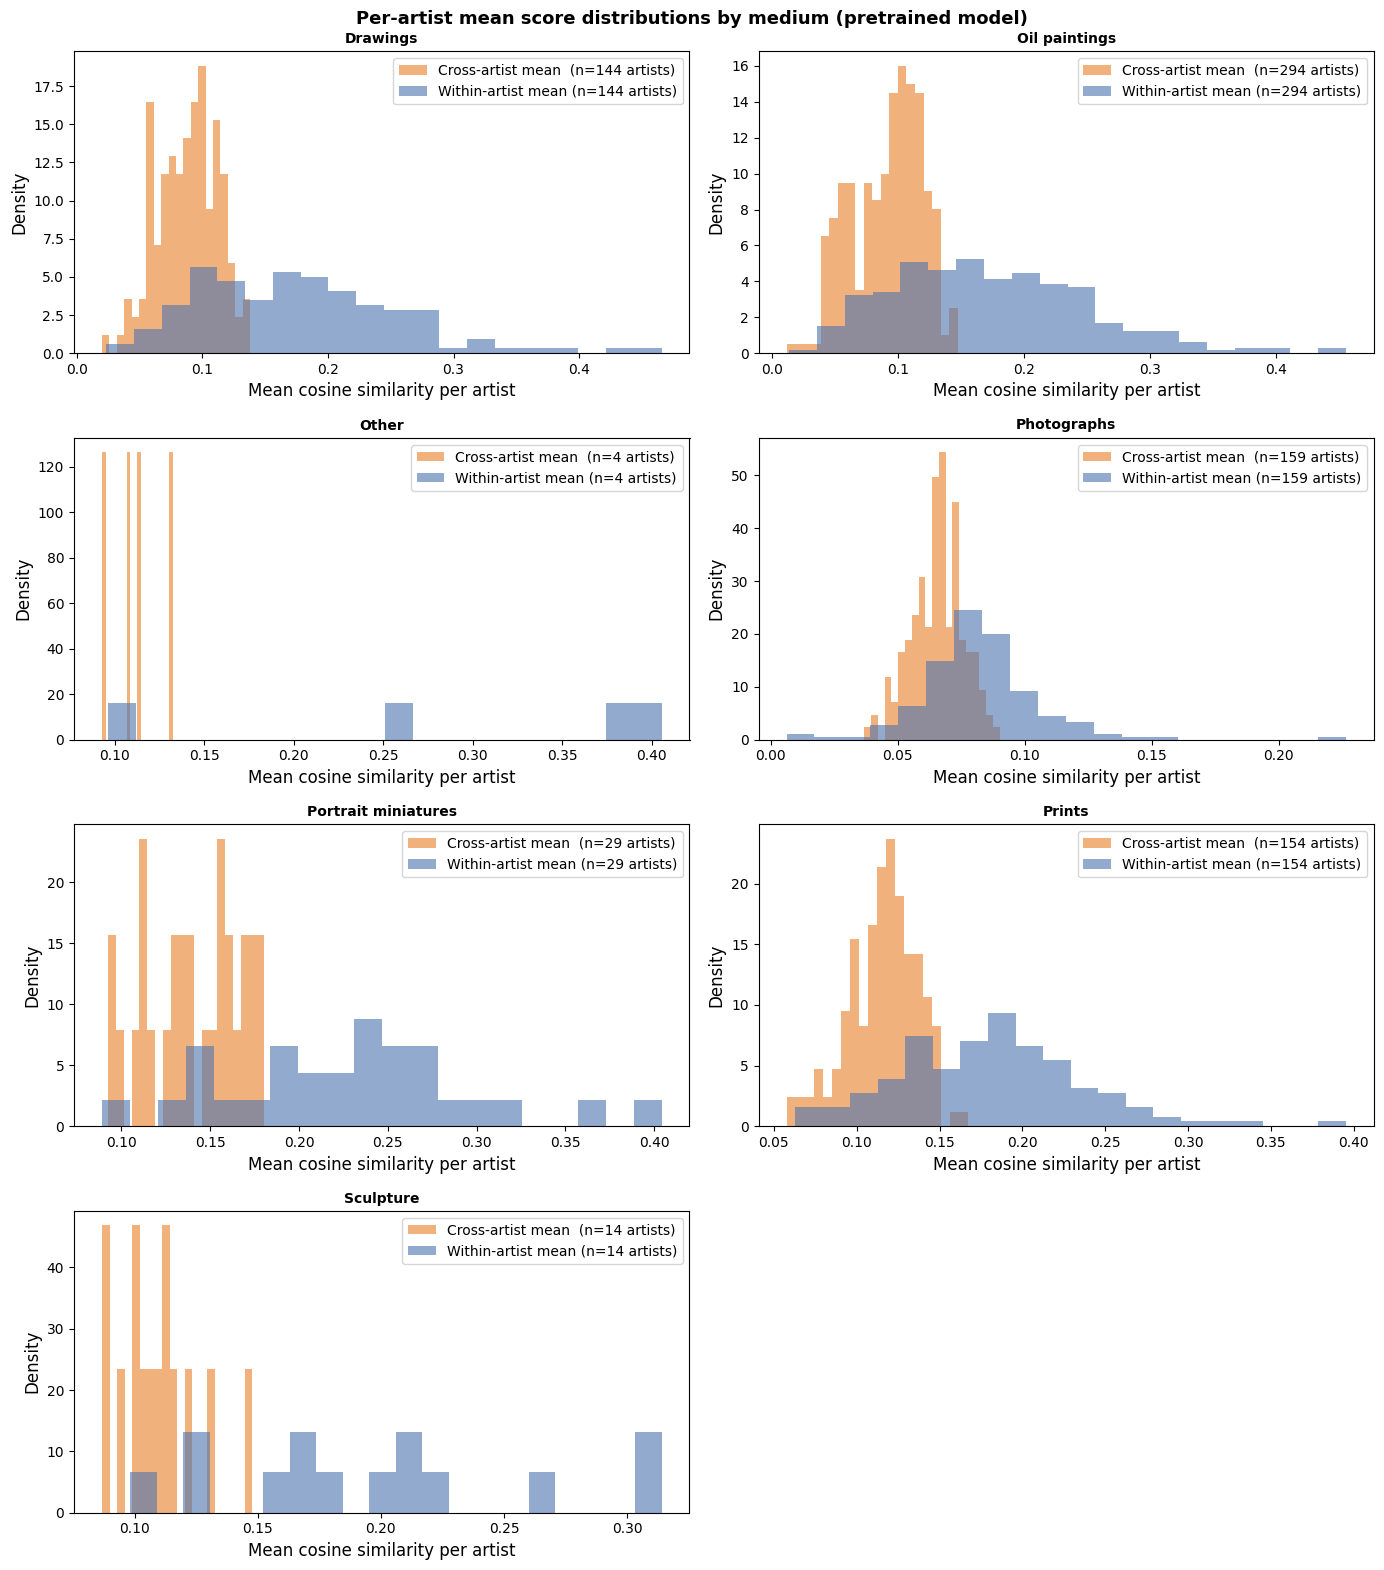

In [10]:
within_tagged_exp4, cross_tagged_med_exp4 = build_medium_tagged_artist_pairs(
    bias_exp4['df5'], bias_exp4['within_pairs'], bias_exp4['qualifying'])

df_exp4b, medium_data_exp4b = medium_bias_table(within_tagged_exp4, cross_tagged_med_exp4, emb_pretrained)
display(df_exp4b.style.format({'Mean within':'{:.4f}','Mean cross':'{:.4f}','Mean delta':'{:+.4f}','p-value':'{:.4f}','N artists':'{:,}'}))

media_list_exp4b = list(medium_data_exp4b.keys())
pos_w, pos_c, box_w, box_c = [], [], [], []
for i, medium in enumerate(media_list_exp4b):
    pos_w.append(i*3+0.75); pos_c.append(i*3+1.75)
    box_w.append(medium_data_exp4b[medium]['wm']); box_c.append(medium_data_exp4b[medium]['cm'])

fig, ax = plt.subplots(figsize=(13, 6))
ax.boxplot(box_w, positions=pos_w, widths=0.7, patch_artist=True,
           boxprops=dict(facecolor=MODEL_COLORS['Pretrained'], alpha=0.6), medianprops=dict(color='black', lw=1.5))
ax.boxplot(box_c, positions=pos_c, widths=0.7, patch_artist=True,
           boxprops=dict(facecolor='#E87D27', alpha=0.6), medianprops=dict(color='black', lw=1.5))
ax.set_xticks([i*3+1.25 for i in range(len(media_list_exp4b))])
ax.set_xticklabels(media_list_exp4b, rotation=15, ha='right', fontsize=11)
ax.set_ylabel('Per-artist mean cosine similarity')
ax.set_title('Within- vs. cross-artist impostor scores by medium (pretrained model)')
ax.legend([Patch(facecolor=MODEL_COLORS['Pretrained'], alpha=0.6), Patch(facecolor='#E87D27', alpha=0.6)],
          ['Within-artist', 'Cross-artist'], fontsize=10)
plt.tight_layout(); plt.show()

# Per-medium score-distribution histograms (per-artist mean impostor scores)
ncols = 2
nrows = (len(medium_data_exp4b) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()
for i, medium in enumerate(media_list_exp4b):
    ax = axes[i]
    d  = medium_data_exp4b[medium]
    ax.hist(d['cm'], bins=20, density=True, alpha=0.6, color='#E87D27',
            label=f'Cross-artist mean  (n={len(d["cm"])} artists)')
    ax.hist(d['wm'], bins=20, density=True, alpha=0.6, color=MODEL_COLORS['Pretrained'],
            label=f'Within-artist mean (n={len(d["wm"])} artists)')
    ax.set_title(medium, fontsize=10)
    ax.set_xlabel('Mean cosine similarity per artist')
    ax.set_ylabel('Density')
    ax.legend(fontsize=10)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Per-artist mean score distributions by medium (pretrained model)', fontsize=13)
plt.tight_layout(); plt.show()

### EXP5: Difficulty of genuine pairs

AUC/EER compared for within-artist vs. cross-artist genuine pairs, against the same shared impostor pool (EXP4a's cross-artist impostor pairs), so any difference is attributable to the genuine-pair condition alone.

- **Within-artist genuine**: same sitter, same artist — model sees same style + same identity
- **Cross-artist genuine**: same sitter, different artists — model sees different style, only identity signal

Both conditions are evaluated against the **same shared impostor pool** (cross-artist impostors from EXP5a), so any AUC/EER difference isolates the effect of genuine pair type.

Within-artist genuine pairs: 28,595
Cross-artist genuine pairs:  139,951
Shared impostor pairs:       131,600


,Condition,N genuine,N impostor,AUC,EER,TAR@1%,TAR@0.1%
0,Within-artist genuine,"28,595","131,600",0.9677,0.0938,0.7558,0.5924
1,Cross-artist genuine,"139,951","131,600",0.9316,0.1446,0.5602,0.3450



Mann-Whitney U (within genuine > cross genuine): U=2687248640.0, p=0.0000
--> Within-artist genuine pairs score significantly higher (style shortcut confirmed)


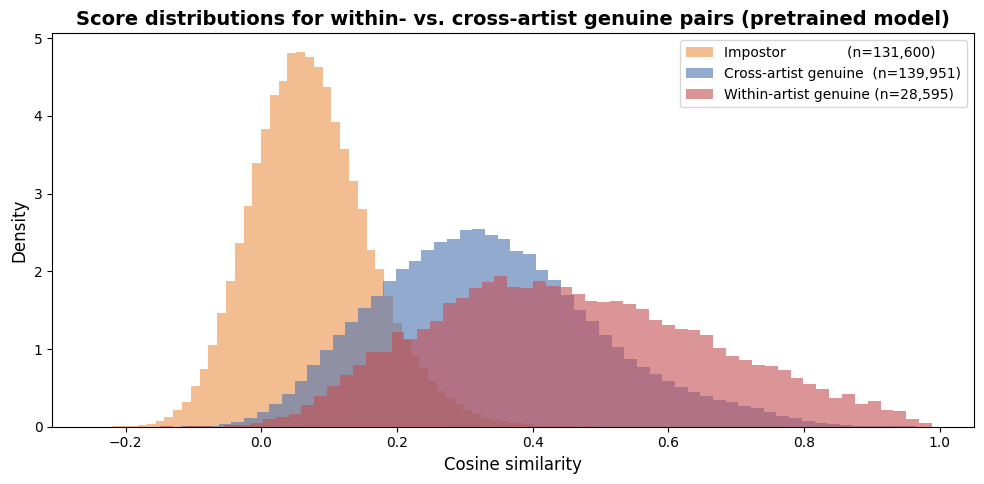

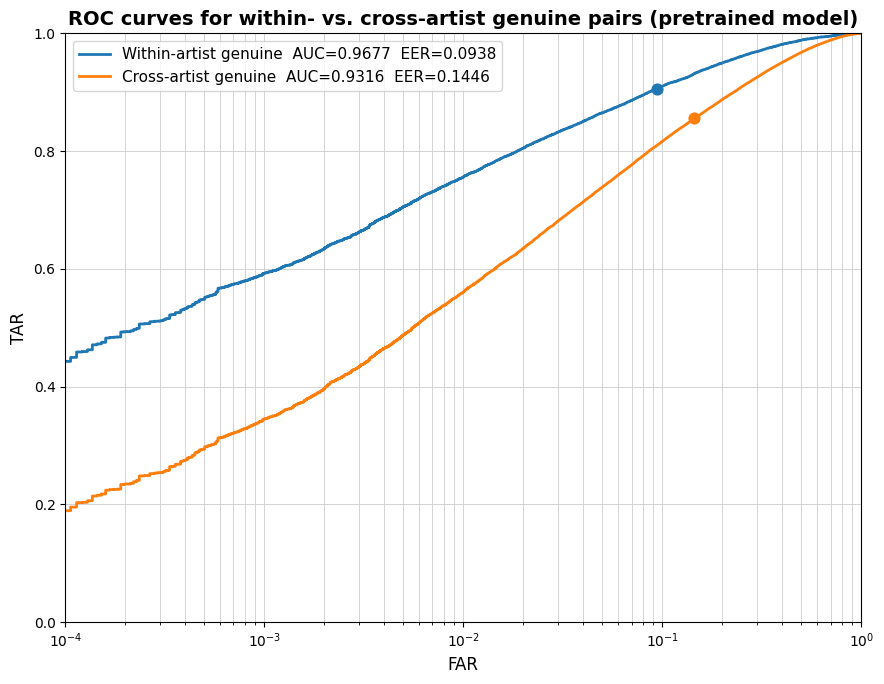

In [11]:
within_genuine_exp5, cross_genuine_exp5 = build_artist_genuine_pairs(df)
impostor_pairs_exp5 = [(la, lb, 0, sa, sb) for la, lb, _, sa, sb in bias_exp4['cross_pairs']]

print(f'Within-artist genuine pairs: {len(within_genuine_exp5):,}')
print(f'Cross-artist genuine pairs:  {len(cross_genuine_exp5):,}')
print(f'Shared impostor pairs:       {len(impostor_pairs_exp5):,}')

sc_w, lb_w, sa_w, sb_w = score_pairs(within_genuine_exp5 + impostor_pairs_exp5, emb_pretrained)
sc_c, lb_c, sa_c, sb_c = score_pairs(cross_genuine_exp5  + impostor_pairs_exp5, emb_pretrained)
m_w_exp5 = compute_metrics(sc_w, lb_w, sa_w, sb_w)
m_c_exp5 = compute_metrics(sc_c, lb_c, sa_c, sb_c)
log_scorecard('EXP5', 'Within-artist genuine', 'Pretrained', m_w_exp5)
log_scorecard('EXP5', 'Cross-artist genuine',  'Pretrained', m_c_exp5)

display(pd.DataFrame([
    {'Condition':'Within-artist genuine', 'N genuine':int(lb_w.sum()), 'N impostor':int((lb_w==0).sum()),
     'AUC':m_w_exp5['AUC'], 'EER':m_w_exp5['EER'], 'TAR@1%':m_w_exp5['TAR@1%'], 'TAR@0.1%':m_w_exp5['TAR@0.1%']},
    {'Condition':'Cross-artist genuine', 'N genuine':int(lb_c.sum()), 'N impostor':int((lb_c==0).sum()),
     'AUC':m_c_exp5['AUC'], 'EER':m_c_exp5['EER'], 'TAR@1%':m_c_exp5['TAR@1%'], 'TAR@0.1%':m_c_exp5['TAR@0.1%']},
]).style.format({'AUC':'{:.4f}','EER':'{:.4f}','TAR@1%':'{:.4f}','TAR@0.1%':'{:.4f}','N genuine':'{:,}','N impostor':'{:,}'}))

gen_w_scores, gen_c_scores = sc_w[lb_w==1], sc_c[lb_c==1]
stat5, p5 = mannwhitneyu(gen_w_scores, gen_c_scores, alternative='greater')
print(f'\nMann-Whitney U (within genuine > cross genuine): U={stat5:.1f}, p={p5:.4f}')
print('--> Within-artist genuine pairs score significantly higher (style shortcut confirmed)'
      if p5 < 0.05 else '--> No significant difference')

# Score distributions: impostor pool vs. cross-artist genuine vs. within-artist genuine
imp_scores_exp5 = sc_w[lb_w == 0]  # same shared impostor pool for both conditions
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(imp_scores_exp5, bins=60, density=True, alpha=0.5, color='#E87D27',
        label=f'Impostor              (n={len(imp_scores_exp5):,})')
ax.hist(gen_c_scores, bins=60, density=True, alpha=0.6, color='#4C72B0',
        label=f'Cross-artist genuine  (n={len(gen_c_scores):,})')
ax.hist(gen_w_scores, bins=60, density=True, alpha=0.6, color='#C44E52',
        label=f'Within-artist genuine (n={len(gen_w_scores):,})')
ax.set_xlabel('Cosine similarity'); ax.set_ylabel('Density')
ax.set_title('Score distributions for within- vs. cross-artist genuine pairs (pretrained model)')
ax.legend(); plt.tight_layout(); plt.show()

plot_combined_roc({'Within-artist genuine': m_w_exp5, 'Cross-artist genuine': m_c_exp5},
                   title='ROC curves for within- vs. cross-artist genuine pairs (pretrained model)')

---
# RQ2: Fine-tuned ResNet100

Evaluated on the **test split only** (5,136 portraits, 1,596 sitters) — the fine-tuning used the train split, so only held-out data gives a leakage-free evaluation. Every comparison cell below independently rebuilds a Pretrained baseline on this same test split, so "compared directly to EXP X" is always on matched data.

### EXP6: Overall evaluation

ResNet100 fine-tuned on all RKD training-split portraits (mixed media), evaluated on the full test set. Compared directly to EXP1 — using a fresh Pretrained-on-test-split baseline computed here, not EXP1's full-dataset number.

Pairs built — genuine: 14,593  impostor: 145,930  ratio: 1:10


,Model,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%,Δ vs Pretrained (AUC)
0,Pretrained,0.9445,0.9521,0.1270,0.6337,0.4397,+0.0000
1,Fine-tuned,0.9462,0.9420,0.1241,0.6507,0.4412,+0.0017


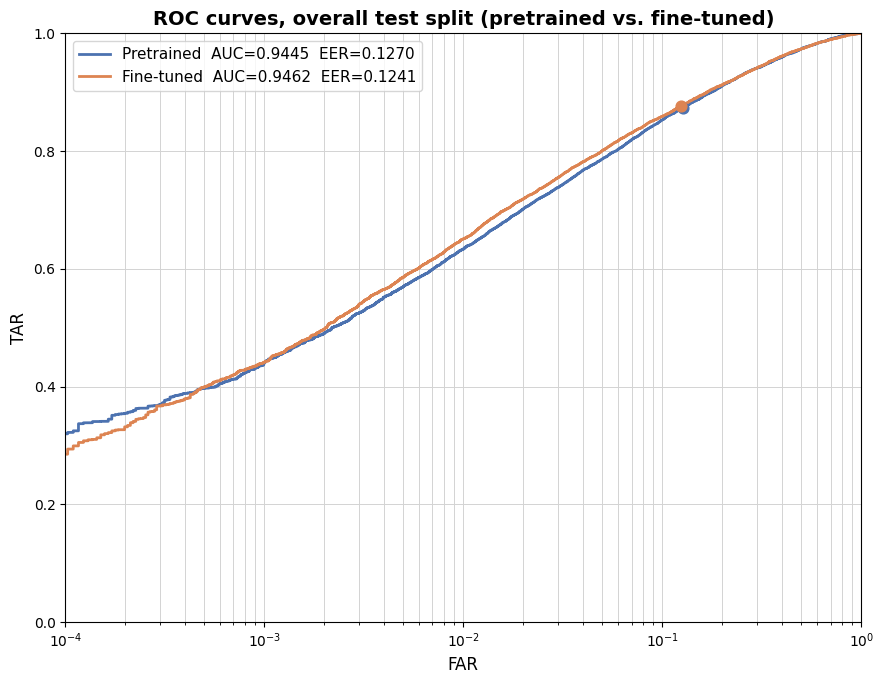

In [12]:
pairs_test_full = build_pairs(df_test, impostor_ratio=10, seed=42)

models_exp6 = [('Pretrained', emb_pretrained), ('Fine-tuned', emb_finetuned)]
roc_exp6 = {}
rows_exp6 = []
for name, emb in models_exp6:
    sc, lb, sa, sb = score_pairs(pairs_test_full, emb)
    m = compute_metrics(sc, lb, sa, sb)
    roc_exp6[name] = m
    log_scorecard('EXP6', 'Test split (overall)', name, m)
    rows_exp6.append({'Model': name, 'AUC': m['AUC'], 'Macro-AUC': m['macro_AUC'], 'EER': m['EER'],
                       'TAR@1%': m['TAR@1%'], 'TAR@0.1%': m['TAR@0.1%']})

df_exp6 = pd.DataFrame(rows_exp6)
df_exp6['Δ vs Pretrained (AUC)'] = df_exp6['AUC'] - df_exp6.loc[df_exp6['Model']=='Pretrained','AUC'].values[0]
display(df_exp6.style.format({'AUC':'{:.4f}','Macro-AUC':'{:.4f}','EER':'{:.4f}','TAR@1%':'{:.4f}','TAR@0.1%':'{:.4f}',
                               'Δ vs Pretrained (AUC)':'{:+.4f}'}))
plot_combined_roc(roc_exp6, title='ROC curves, overall test split (pretrained vs. fine-tuned)')

### RQ2a: Does fine-tuning reduce the performance gap between media?

### EXP7: Stratified evaluation by medium

Repeats EXP2 on the test split, comparing Pretrained and Fine-tuned.

Pairs built — genuine: 2,696  impostor: 26,960  ratio: 1:10
Pairs built — genuine: 2,179  impostor: 21,790  ratio: 1:10
Pairs built — genuine: 1,680  impostor: 16,800  ratio: 1:10
Pairs built — genuine: 958  impostor: 9,580  ratio: 1:10
Pairs built — genuine: 99  impostor: 990  ratio: 1:10
Pairs built — genuine: 34  impostor: 340  ratio: 1:10
Pairs built — genuine: 8  impostor: 80  ratio: 1:10


,AUC (Pretrained),AUC (Fine-tuned),ΔAUC,ΔMacro-AUC,ΔEER,ΔTAR@1%,ΔTAR@0.1%
Stratum,,,,,,,
Oil paintings,0.9553,0.9618,+0.0065,-0.0101,-0.0156,+0.0505,+0.0052
Photographs,0.9719,0.9724,+0.0005,-0.0012,+0.0110,-0.0532,-0.0927
Prints,0.9519,0.9562,+0.0043,+0.0035,-0.0047,+0.0101,-0.0286
Drawings,0.9486,0.9499,+0.0013,+0.0005,-0.0040,+0.0323,+0.0281
Portrait miniatures,0.9121,0.9294,+0.0173,+0.0107,-0.0187,+0.0101,-0.0303
Sculpture,0.8565,0.8651,+0.0086,-0.0204,+0.0676,+0.0000,-0.0588
Other,0.8031,0.8391,+0.0360,+0.0410,+0.0500,+0.0000,+0.0000


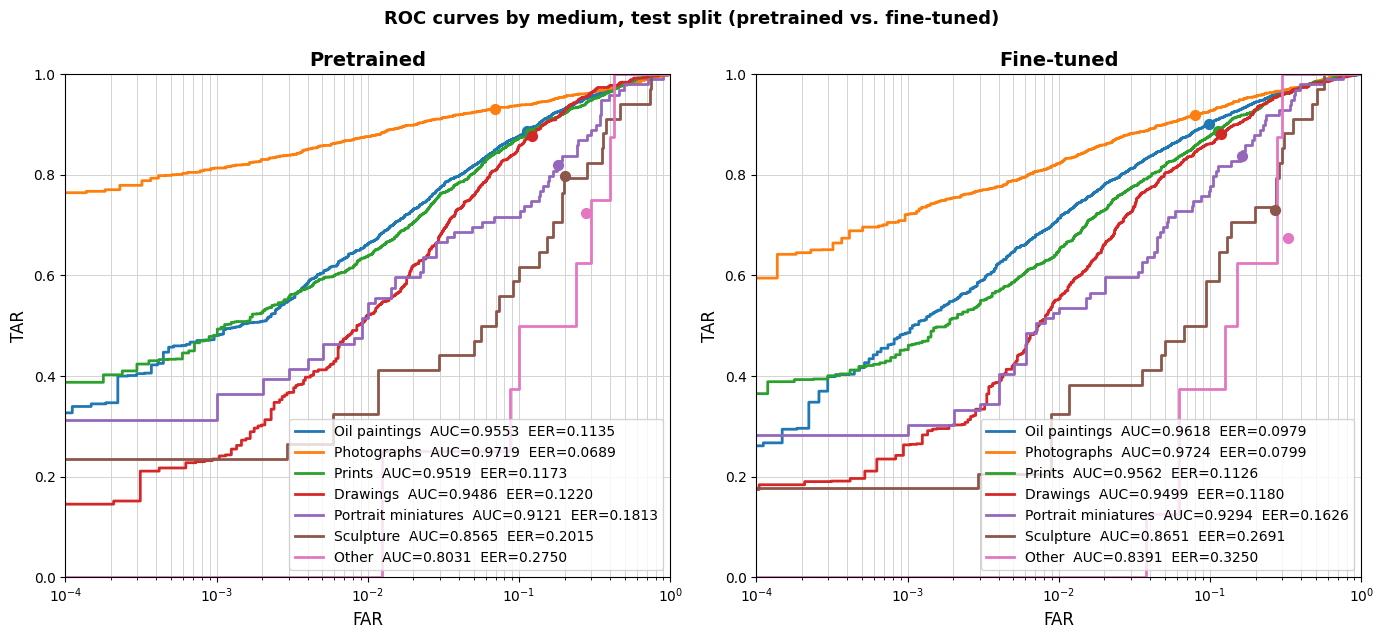

In [13]:
media_exp7 = (df_test.groupby('medium_group')['lref'].count()
                .sort_values(ascending=False).index.tolist())

strata_pairs_test = {}
for medium in media_exp7:
    subset = df_test[df_test['medium_group'] == medium]
    if subset['sitter_id'].nunique() < 2:
        continue
    strata_pairs_test[medium] = build_pairs(subset, impostor_ratio=10, seed=42)

long_exp7 = compare_models_by_stratum(strata_pairs_test, [('Pretrained', emb_pretrained), ('Fine-tuned', emb_finetuned)])
for _, r in long_exp7.iterrows():
    log_scorecard('EXP7', r['Stratum'], r['Model'],
                   {'AUC': r['AUC'], 'macro_AUC': r['Macro-AUC'], 'EER': r['EER'],
                    'TAR@1%': r['TAR@1%'], 'TAR@0.1%': r['TAR@0.1%']})

rows_wide7 = []
for stratum in long_exp7['Stratum'].unique():
    sub = long_exp7[long_exp7['Stratum'] == stratum].set_index('Model')
    pre, ft = sub.loc['Pretrained'], sub.loc['Fine-tuned']
    rows_wide7.append({
        'Stratum': stratum,
        'AUC (Pretrained)': pre['AUC'], 'AUC (Fine-tuned)': ft['AUC'], 'ΔAUC': ft['AUC'] - pre['AUC'],
        'ΔMacro-AUC': ft['Macro-AUC'] - pre['Macro-AUC'],
        'ΔEER': ft['EER'] - pre['EER'],
        'ΔTAR@1%': ft['TAR@1%'] - pre['TAR@1%'],
        'ΔTAR@0.1%': ft['TAR@0.1%'] - pre['TAR@0.1%'],
    })
wide_exp7 = pd.DataFrame(rows_wide7).set_index('Stratum')
delta_cols7 = [c for c in wide_exp7.columns if c.startswith('Δ')]
display(wide_exp7.style.format({c: '{:.4f}' for c in ['AUC (Pretrained)', 'AUC (Fine-tuned)']}
                                | {c: '{:+.4f}' for c in delta_cols7}))

plot_roc_panels(strata_pairs_test, [('Pretrained', emb_pretrained), ('Fine-tuned', emb_finetuned)],
                suptitle='ROC curves by medium, test split (pretrained vs. fine-tuned)')

### EXP8: Cross-medium genuine pairs

Repeats EXP3 on the test split, comparing Pretrained and Fine-tuned.

  Cross-medium (Oil paintings × Prints) — shared sitters: 177  genuine: 1,936  impostor: 19,360
  Cross-medium (Oil paintings × Drawings) — shared sitters: 286  genuine: 1,715  impostor: 17,150
  Cross-medium (Oil paintings × Photographs) — shared sitters: 115  genuine: 431  impostor: 4,310
  Cross-medium (Drawings × Prints) — shared sitters: 85  genuine: 422  impostor: 4,220
  Cross-medium (Photographs × Prints) — shared sitters: 38  genuine: 507  impostor: 5,070
  Cross-medium (Drawings × Photographs) — shared sitters: 80  genuine: 293  impostor: 2,930


Model,Fine-tuned,Oil-only,Pretrained,Δ Fine-tuned,Δ Oil-only
Stratum,,,,,
Drawings × Photographs,0.8867,0.7587,0.8569,0.0298,-0.0982
Drawings × Prints,0.9253,0.8757,0.9301,-0.0048,-0.0544
Oil paintings × Drawings,0.9358,0.9085,0.9272,0.0086,-0.0187
Oil paintings × Photographs,0.9054,0.8484,0.9039,0.0015,-0.0555
Oil paintings × Prints,0.9315,0.8791,0.9347,-0.0032,-0.0556
Photographs × Prints,0.9472,0.8611,0.9147,0.0325,-0.0536


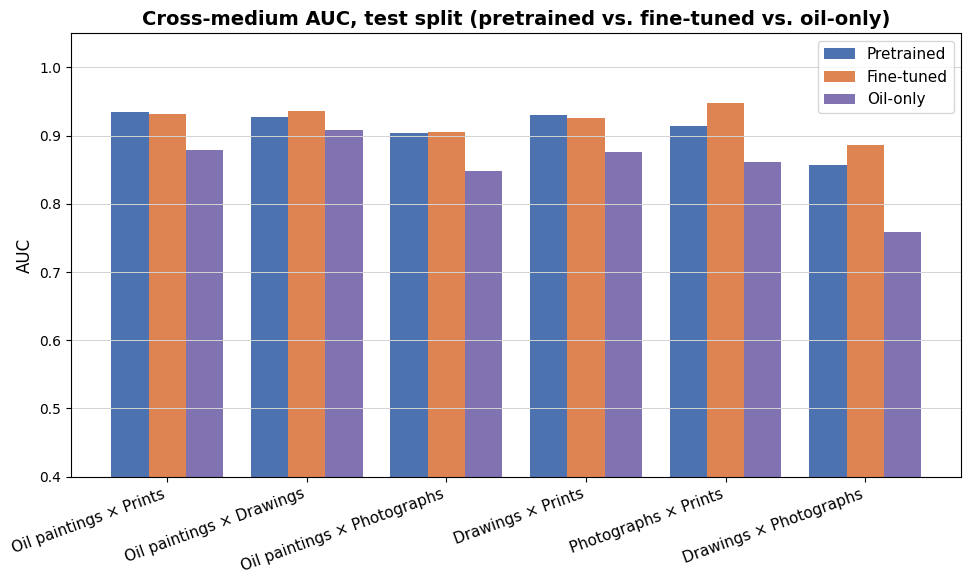

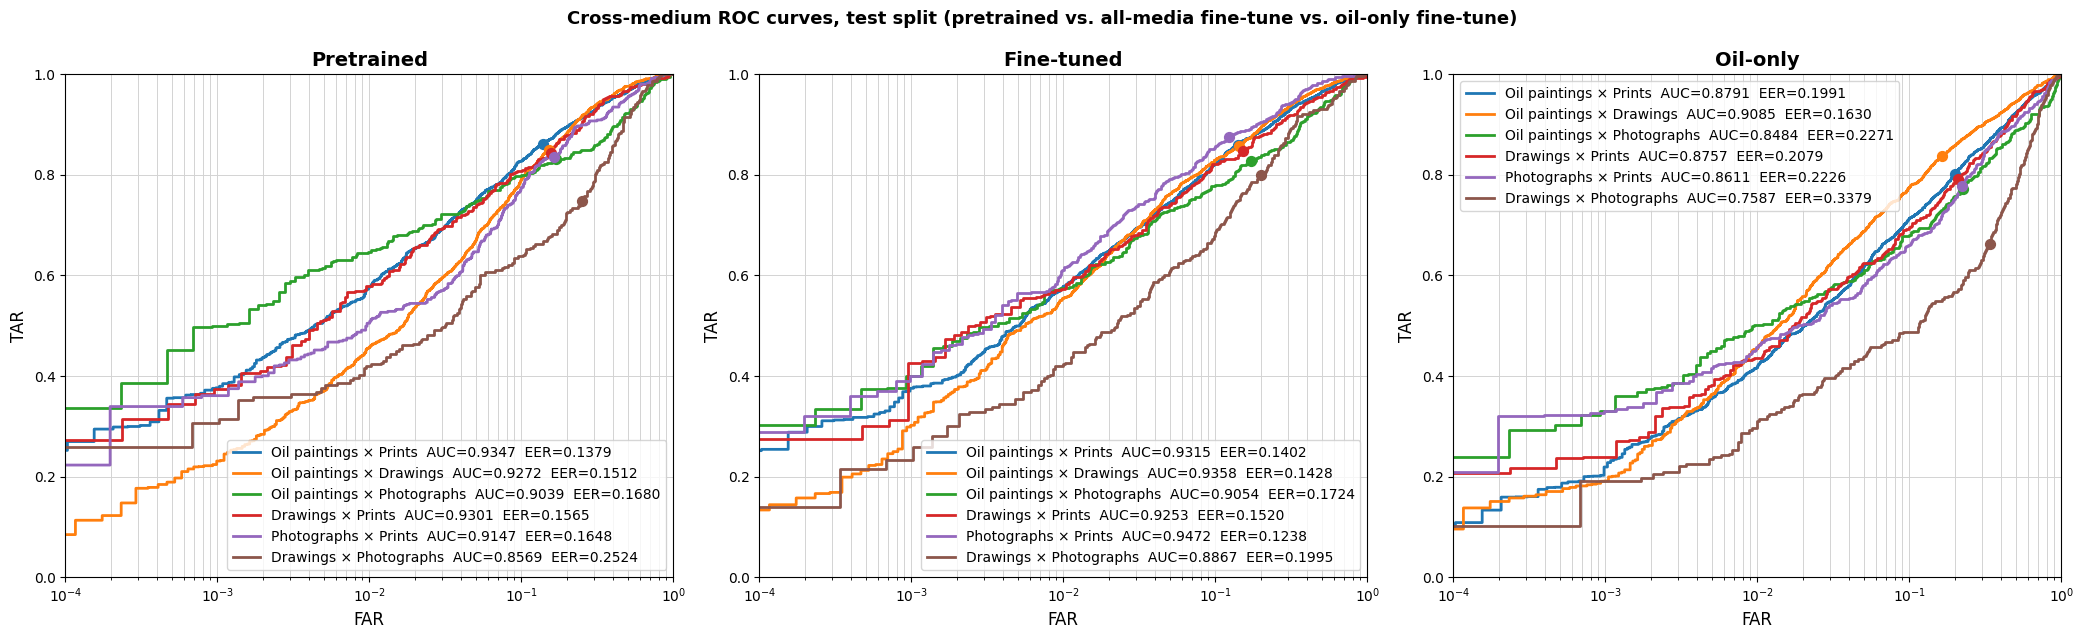

In [14]:
strata_pairs_cross_test = {}
for a, b in combos_exp3:
    pairs = build_cross_medium_pairs(df_test, 'medium_group', a, b, impostor_ratio=10, seed=42)
    if pairs:
        strata_pairs_cross_test[f'{a} × {b}'] = pairs

models_exp8 = [('Pretrained', emb_pretrained), ('Fine-tuned', emb_finetuned), ('Oil-only', emb_oilonly)]
long_exp8 = compare_models_by_stratum(strata_pairs_cross_test, models_exp8)
for _, r in long_exp8.iterrows():
    log_scorecard('EXP8', r['Stratum'], r['Model'],
                   {'AUC': r['AUC'], 'macro_AUC': r['Macro-AUC'], 'EER': r['EER'],
                    'TAR@1%': r['TAR@1%'], 'TAR@0.1%': r['TAR@0.1%']})

display(wide_with_deltas(long_exp8, 'AUC').style.format('{:.4f}'))
plot_grouped_bars(long_exp8, 'AUC', title='Cross-medium AUC, test split (pretrained vs. fine-tuned vs. oil-only)', ylim=[0.4,1.05])

plot_roc_panels(strata_pairs_cross_test, models_exp8,
                suptitle='Cross-medium ROC curves, test split (pretrained vs. all-media fine-tune vs. oil-only fine-tune)')

### EXP9: Medium-specific fine-tuning

ResNet100 fine-tuned on oil paintings only (same train/test split as EXP6), tested on the oil-paintings test subset. Tests whether medium-specific specialization helps compared to the all-media fine-tune. Compared to EXP7's oil-paintings row.

Pairs built — genuine: 2,696  impostor: 26,960  ratio: 1:10


,Model,Portraits,Sitters,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%,Δ vs Pretrained (AUC)
0,Pretrained,"1,751",877,0.9553,0.9543,0.1135,0.6628,0.4800,+0.0000
1,Fine-tuned,"1,751",877,0.9618,0.9442,0.0979,0.7133,0.4852,+0.0065
2,Oil-only,"1,751",877,0.9460,0.9327,0.1245,0.6595,0.4648,-0.0093



Compare 'Fine-tuned' row above to EXP7's Oil-paintings row (should match if using the same test pairs / seed).


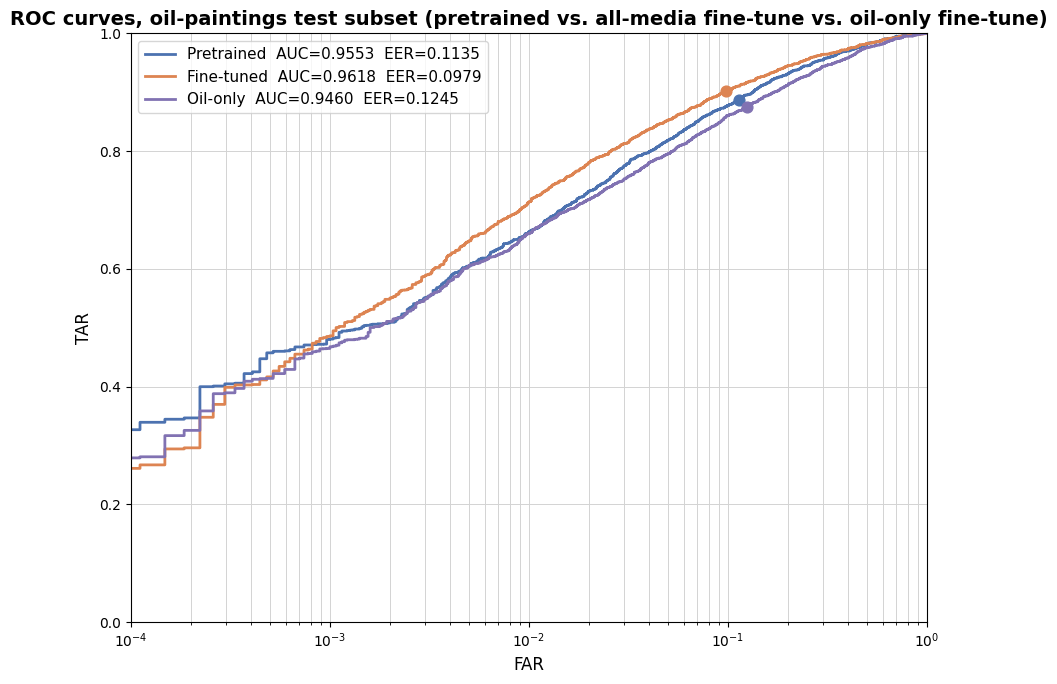

In [15]:
subset_oil_test = df_test[df_test['medium_group'] == 'Oil paintings']
pairs_oil_test  = build_pairs(subset_oil_test, impostor_ratio=10, seed=42)

models_exp9 = [('Pretrained', emb_pretrained), ('Fine-tuned', emb_finetuned), ('Oil-only', emb_oilonly)]
rows_exp9 = []
roc_exp9 = {}
for name, emb in models_exp9:
    sc, lb, sa, sb = score_pairs(pairs_oil_test, emb)
    m = compute_metrics(sc, lb, sa, sb)
    roc_exp9[name] = m
    log_scorecard('EXP9', 'Oil paintings (test)', name, m)
    rows_exp9.append({'Model': name, 'Portraits': len(subset_oil_test), 'Sitters': subset_oil_test['sitter_id'].nunique(),
                       'AUC': m['AUC'], 'Macro-AUC': m['macro_AUC'], 'EER': m['EER'],
                       'TAR@1%': m['TAR@1%'], 'TAR@0.1%': m['TAR@0.1%']})

df_exp9 = pd.DataFrame(rows_exp9)
baseline_auc = df_exp9.loc[df_exp9['Model']=='Pretrained','AUC'].values[0]
df_exp9['Δ vs Pretrained (AUC)'] = df_exp9['AUC'] - baseline_auc
display(df_exp9.style.format({'AUC':'{:.4f}','Macro-AUC':'{:.4f}','EER':'{:.4f}','TAR@1%':'{:.4f}','TAR@0.1%':'{:.4f}',
                               'Δ vs Pretrained (AUC)':'{:+.4f}','Portraits':'{:,}','Sitters':'{:,}'}))
print(f"\nCompare 'Fine-tuned' row above to EXP7's Oil-paintings row "
      f"(should match if using the same test pairs / seed).")

plot_combined_roc(roc_exp9, title='ROC curves, oil-paintings test subset (pretrained vs. all-media fine-tune vs. oil-only fine-tune)')

### RQ2b: Does fine-tuning reduce or amplify artist bias?

### EXP10: Artist bias and genuine pair difficulty (fine-tuned model)

Repeats EXP4 and EXP5 using the fine-tuned model, on artist-bias pairs rebuilt from the **test split only** (fixing the leakage issue from the previous notebook, where these pairs were built from the full dataset including train-split sitters the fine-tuned model had already seen).

- **EXP10a** (↔ EXP4a): within- vs. cross-artist impostor scores.
- **EXP10b** (↔ EXP4b): the same, by medium.
- **EXP10c** (↔ EXP5): within- vs. cross-artist genuine-pair difficulty.

  Qualifying artists (>=5 sitters, excl. Anoniem): 110
  Portraits in filtered set: 1,637
  Within-artist impostor pairs: 18,524
  Cross-artist impostor pairs:  22,000
(Note the much smaller qualifying-artist count vs. EXP4 — expected, given the test split is ~19% of the full dataset.)


,Model,Group,N artists,Mean
0,Pretrained,Within-artist,110,0.1418
1,Pretrained,Cross-artist,110,0.0732
2,Fine-tuned,Within-artist,110,0.0557
3,Fine-tuned,Cross-artist,110,0.0019



Mann-Whitney U (within > cross), Pretrained: U=9548.0, p=0.0000
  --> Within-artist impostor scores are significantly higher (artist bias detected)
Mann-Whitney U (within > cross), Fine-tuned:  U=11733.0, p=0.0000
  --> Within-artist impostor scores are significantly higher (artist bias detected)

Pretrained (test split):  within/cross ratio = 1.94x
Fine-tuned:                 within/cross ratio = 29.60x
(A ratio near a very small denominator is unstable — check the absolute gap too, not just the ratio.)
Pretrained absolute gap: 0.0686
Fine-tuned absolute gap: 0.0538


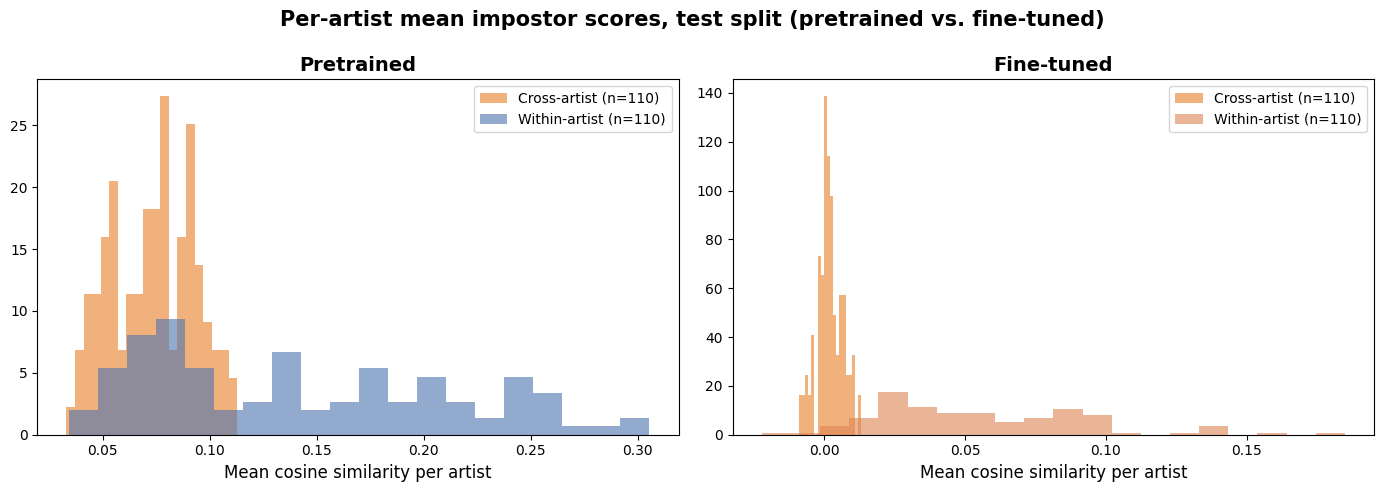

In [16]:
bias_exp10 = build_artist_bias_pairs(df_test, min_sitters=5, cross_sample=200, seed=42)
print('(Note the much smaller qualifying-artist count vs. EXP4 — expected, given the test split is ~19% of the full dataset.)')

res_exp10a_pre = artist_bias_summary(bias_exp10, emb_pretrained)
res_exp10a_ft  = artist_bias_summary(bias_exp10, emb_finetuned)

display(pd.DataFrame({
    'Model':               ['Pretrained', 'Pretrained', 'Fine-tuned', 'Fine-tuned'],
    'Group':               ['Within-artist', 'Cross-artist', 'Within-artist', 'Cross-artist'],
    'N artists':           [len(res_exp10a_pre['wm']), len(res_exp10a_pre['cm']), len(res_exp10a_ft['wm']), len(res_exp10a_ft['cm'])],
    'Mean':                [round(float(np.mean(res_exp10a_pre['wm'])),4), round(float(np.mean(res_exp10a_pre['cm'])),4),
                             round(float(np.mean(res_exp10a_ft['wm'])),4),  round(float(np.mean(res_exp10a_ft['cm'])),4)],
}))
print(f"\nMann-Whitney U (within > cross), Pretrained: U={res_exp10a_pre['stat']:.1f}, p={res_exp10a_pre['p']:.4f}")
print('  --> Within-artist impostor scores are significantly higher (artist bias detected)'
      if res_exp10a_pre['p'] < 0.05 else '  --> No significant difference')
print(f"Mann-Whitney U (within > cross), Fine-tuned:  U={res_exp10a_ft['stat']:.1f}, p={res_exp10a_ft['p']:.4f}")
print('  --> Within-artist impostor scores are significantly higher (artist bias detected)'
      if res_exp10a_ft['p'] < 0.05 else '  --> No significant difference')

print(f"\nPretrained (test split):  within/cross ratio = {np.mean(res_exp10a_pre['wm'])/max(np.mean(res_exp10a_pre['cm']),1e-9):.2f}x")
print(f"Fine-tuned:                 within/cross ratio = {np.mean(res_exp10a_ft['wm'])/max(np.mean(res_exp10a_ft['cm']),1e-9):.2f}x")
print('(A ratio near a very small denominator is unstable — check the absolute gap too, not just the ratio.)')
print(f"Pretrained absolute gap: {np.mean(res_exp10a_pre['wm'])-np.mean(res_exp10a_pre['cm']):.4f}")
print(f"Fine-tuned absolute gap: {np.mean(res_exp10a_ft['wm'])-np.mean(res_exp10a_ft['cm']):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, res) in zip(axes, [('Pretrained', res_exp10a_pre), ('Fine-tuned', res_exp10a_ft)]):
    ax.hist(res['cm'], bins=20, density=True, alpha=0.6, color='#E87D27', label=f"Cross-artist (n={len(res['cm'])})")
    ax.hist(res['wm'], bins=20, density=True, alpha=0.6, color=MODEL_COLORS[name], label=f"Within-artist (n={len(res['wm'])})")
    ax.set_title(name); ax.set_xlabel('Mean cosine similarity per artist'); ax.legend(fontsize=10)
plt.suptitle('Per-artist mean impostor scores, test split (pretrained vs. fine-tuned)')
plt.tight_layout(); plt.show()

In [17]:
within_tagged_exp10, cross_tagged_med_exp10 = build_medium_tagged_artist_pairs(
    bias_exp10['df5'], bias_exp10['within_pairs'], bias_exp10['qualifying'])

df_exp10b_pre, _ = medium_bias_table(within_tagged_exp10, cross_tagged_med_exp10, emb_pretrained)
df_exp10b_ft,  _ = medium_bias_table(within_tagged_exp10, cross_tagged_med_exp10, emb_finetuned)
df_exp10b_pre['Model'] = 'Pretrained'; df_exp10b_ft['Model'] = 'Fine-tuned'
df_exp10b = pd.concat([df_exp10b_pre, df_exp10b_ft], ignore_index=True)
display(df_exp10b[['Medium','Model','N artists','Mean within','Mean cross','Mean delta','p-value']]
        .style.format({'Mean within':'{:.4f}','Mean cross':'{:.4f}','Mean delta':'{:+.4f}','p-value':'{:.4f}','N artists':'{:,}'}))

# Comparison table to EXP4b (Pretrained, full dataset), alongside the test-split table above
df_exp4b_labeled = df_exp4b.copy()
df_exp4b_labeled['Model'] = 'Pretrained (EXP4b, full dataset)'
df_compare_10b = pd.concat([df_exp4b_labeled, df_exp10b], ignore_index=True)
print('Comparison to EXP4b:')
display(df_compare_10b[['Medium','Model','N artists','Mean within','Mean cross','Mean delta','p-value']]
        .style.format({'Mean within':'{:.4f}','Mean cross':'{:.4f}','Mean delta':'{:+.4f}','p-value':'{:.4f}','N artists':'{:,}'}))

,Medium,Model,N artists,Mean within,Mean cross,Mean delta,p-value
0,Drawings,Pretrained,22,0.1650,0.0883,+0.0766,0.0001
1,Oil paintings,Pretrained,47,0.1717,0.0990,+0.0727,0.0000
2,Photographs,Pretrained,33,0.0690,0.0657,+0.0032,0.1216
3,Prints,Pretrained,23,0.1766,0.1184,+0.0582,0.0000
4,Drawings,Fine-tuned,22,0.0811,0.0078,+0.0733,0.0000
5,Oil paintings,Fine-tuned,47,0.0658,0.0070,+0.0588,0.0000
6,Photographs,Fine-tuned,33,0.0267,0.0182,+0.0086,0.0021
7,Prints,Fine-tuned,23,0.0758,0.0220,+0.0537,0.0000


Comparison to EXP4b:


,Medium,Model,N artists,Mean within,Mean cross,Mean delta,p-value
0,Drawings,"Pretrained (EXP4b, full dataset)",144,0.1765,0.0882,+0.0883,0.0000
1,Oil paintings,"Pretrained (EXP4b, full dataset)",294,0.1737,0.0912,+0.0825,0.0000
2,Other,"Pretrained (EXP4b, full dataset)",4,0.2821,0.1116,+0.1705,0.1000
3,Photographs,"Pretrained (EXP4b, full dataset)",159,0.0825,0.0656,+0.0169,0.0000
4,Portrait miniatures,"Pretrained (EXP4b, full dataset)",29,0.2277,0.1407,+0.0870,0.0000
5,Prints,"Pretrained (EXP4b, full dataset)",154,0.1810,0.1160,+0.0650,0.0000
6,Sculpture,"Pretrained (EXP4b, full dataset)",14,0.1951,0.1090,+0.0861,0.0001
7,Drawings,Pretrained,22,0.1650,0.0883,+0.0766,0.0001
8,Oil paintings,Pretrained,47,0.1717,0.0990,+0.0727,0.0000
9,Photographs,Pretrained,33,0.0690,0.0657,+0.0032,0.1216


In [18]:
within_genuine_exp10, cross_genuine_exp10 = build_artist_genuine_pairs(df_test)
impostor_pairs_exp10 = [(la, lb, 0, sa, sb) for la, lb, _, sa, sb in bias_exp10['cross_pairs']]
print(f'Within-artist genuine pairs: {len(within_genuine_exp10):,}')
print(f'Cross-artist genuine pairs:  {len(cross_genuine_exp10):,}')
print(f'Shared impostor pairs:       {len(impostor_pairs_exp10):,}')

roc_exp10c = {}
rows_exp10c = []
for name, emb in [('Pretrained', emb_pretrained), ('Fine-tuned', emb_finetuned)]:
    sc_w, lb_w, sa_w, sb_w = score_pairs(within_genuine_exp10 + impostor_pairs_exp10, emb)
    sc_c, lb_c, sa_c, sb_c = score_pairs(cross_genuine_exp10  + impostor_pairs_exp10, emb)
    m_w = compute_metrics(sc_w, lb_w, sa_w, sb_w)
    m_c = compute_metrics(sc_c, lb_c, sa_c, sb_c)
    roc_exp10c[f'{name} (within)'] = m_w
    roc_exp10c[f'{name} (cross)']  = m_c
    log_scorecard('EXP10c', 'Within-artist genuine', name, m_w)
    log_scorecard('EXP10c', 'Cross-artist genuine',  name, m_c)
    rows_exp10c.append({'Model': name, 'AUC within': m_w['AUC'], 'AUC cross': m_c['AUC'],
                         'Gap (within-cross)': round(m_w['AUC']-m_c['AUC'],4),
                         'EER within': m_w['EER'], 'EER cross': m_c['EER']})

display(pd.DataFrame(rows_exp10c).style.format({'AUC within':'{:.4f}','AUC cross':'{:.4f}',
                                                  'Gap (within-cross)':'{:+.4f}','EER within':'{:.4f}','EER cross':'{:.4f}'}))

# Comparison table to EXP5 (Pretrained, full dataset), alongside the test-split table above
rows_compare_10c = [{'Model': 'Pretrained (EXP5, full dataset)',
                      'AUC within': m_w_exp5['AUC'], 'AUC cross': m_c_exp5['AUC'],
                      'Gap (within-cross)': round(m_w_exp5['AUC'] - m_c_exp5['AUC'], 4),
                      'EER within': m_w_exp5['EER'], 'EER cross': m_c_exp5['EER']}] + rows_exp10c
print('Comparison to EXP5:')
display(pd.DataFrame(rows_compare_10c).style.format({'AUC within':'{:.4f}','AUC cross':'{:.4f}',
                                                       'Gap (within-cross)':'{:+.4f}','EER within':'{:.4f}','EER cross':'{:.4f}'}))

Within-artist genuine pairs: 4,111
Cross-artist genuine pairs:  10,482
Shared impostor pairs:       22,000


,Model,AUC within,AUC cross,Gap (within-cross),EER within,EER cross
0,Pretrained,0.9612,0.9362,+0.0250,0.1039,0.1375
1,Fine-tuned,0.9651,0.9400,+0.0251,0.0940,0.1305


Comparison to EXP5:


,Model,AUC within,AUC cross,Gap (within-cross),EER within,EER cross
0,"Pretrained (EXP5, full dataset)",0.9677,0.9316,+0.0361,0.0938,0.1446
1,Pretrained,0.9612,0.9362,+0.0250,0.1039,0.1375
2,Fine-tuned,0.9651,0.9400,+0.0251,0.0940,0.1305


---
# RQ3: CLIP+LoRA fusion model

Evaluated on the **test split only**, same reasoning as RQ2 — the fusion model's components (fine-tuned IResNet100, CLIP+LoRA) were trained on the RKD train split. Every cell below compares Pretrained, Fine-tuned, and Fusion together.

Embeddings at `D:/thesis/Swiss_team_rerun_embeddings/`:

| Variable | File | Model | Dim |
|----------|------|-------|-----|
| `emb_ires_pre` | `ires100_embeddings.npy` | IResNet100 pretrained (Glint360k) | 512 |
| `emb_ires_rkd` | `ires100_rkd_embeddings.npy` | IResNet100 fine-tuned on RKD | 512 |
| `emb_clip_base` | `clip_embeddings.npy` | CLIP ViT-B/16, no LoRA | 768 |
| `emb_clip_lora` | `clip_rkd_embeddings.npy` | CLIP ViT-B/16 + LoRA (RKD) | 768 |
| `emb_fusion` | `fusion_rkd_embeddings.npy` | Poh et al. 3-component fusion (IRes pre + IRes ft + CLIP LoRA) | 1792 |

All embeddings are L2-normalised; cosine similarity = dot product. Keys in .npy dicts: `'data/paintings/{sitter_id}_{lref}.jpg'`.

### EXP11: Overall evaluation

The Poh et al. fusion pipeline reproduced on the RKD test set. Compared directly to EXP1 and EXP6.

,Model,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%,Δ vs Pretrained (AUC)
0,Pretrained,0.9445,0.9521,0.1270,0.6337,0.4397,+0.0000
1,Fine-tuned,0.9462,0.9420,0.1241,0.6507,0.4412,+0.0017
2,Fusion,0.9394,0.9530,0.1376,0.5805,0.3774,-0.0051


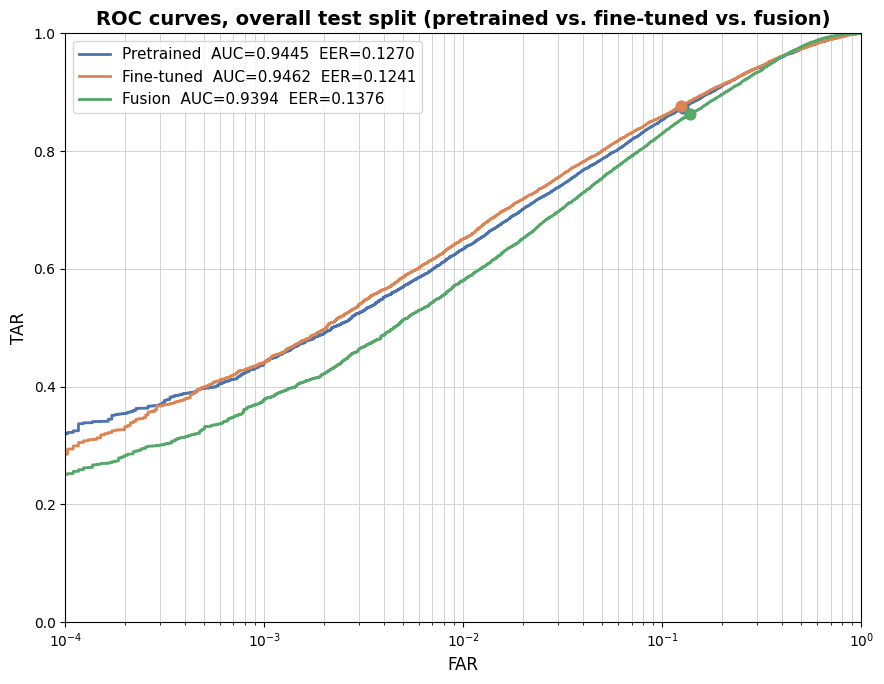

,Model,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%
0,IResNet100 pretrained,0.9445,0.9521,0.1270,0.6337,0.4397
1,IResNet100 fine-tuned,0.9462,0.9420,0.1241,0.6507,0.4412
2,CLIP base (no LoRA),0.8764,0.9126,0.2024,0.3008,0.1268
3,CLIP + LoRA,0.8345,0.8830,0.2563,0.2590,0.0916
4,Fusion (3-component),0.9394,0.9530,0.1376,0.5805,0.3774


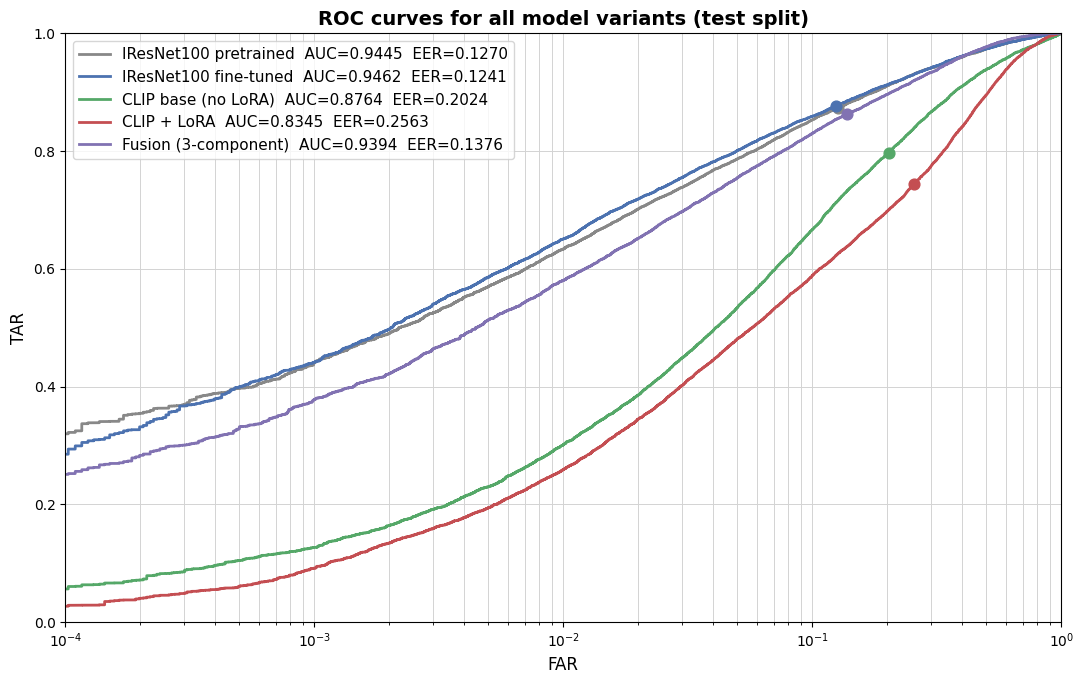

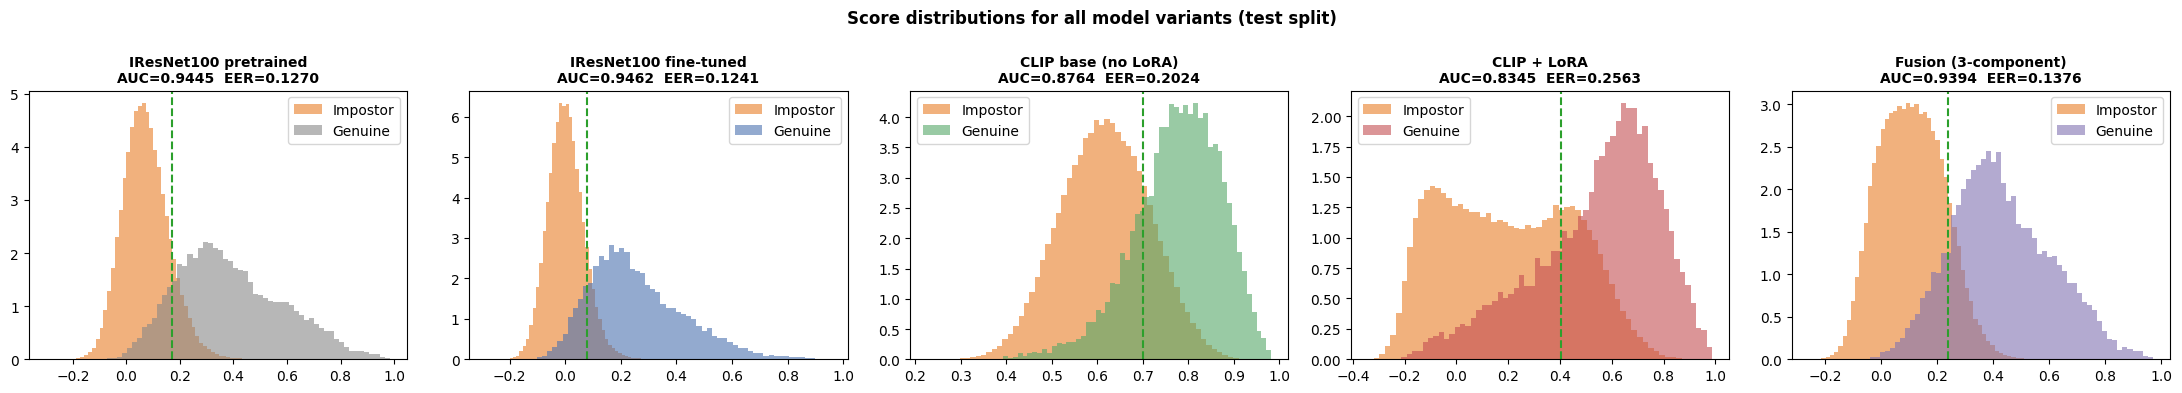

In [19]:
models_exp11 = [('Pretrained', emb_pretrained), ('Fine-tuned', emb_finetuned), ('Fusion', emb_fusion)]
roc_exp11 = {}
rows_exp11 = []
for name, emb in models_exp11:
    sc, lb, sa, sb = score_pairs(pairs_test_full, emb)
    m = compute_metrics(sc, lb, sa, sb)
    roc_exp11[name] = m
    log_scorecard('EXP11', 'Test split (overall)', name, m)
    rows_exp11.append({'Model': name, 'AUC': m['AUC'], 'Macro-AUC': m['macro_AUC'], 'EER': m['EER'],
                        'TAR@1%': m['TAR@1%'], 'TAR@0.1%': m['TAR@0.1%']})

df_exp11 = pd.DataFrame(rows_exp11)
baseline = df_exp11.loc[df_exp11['Model']=='Pretrained','AUC'].values[0]
df_exp11['Δ vs Pretrained (AUC)'] = df_exp11['AUC'] - baseline
display(df_exp11.style.format({'AUC':'{:.4f}','Macro-AUC':'{:.4f}','EER':'{:.4f}','TAR@1%':'{:.4f}','TAR@0.1%':'{:.4f}',
                                'Δ vs Pretrained (AUC)':'{:+.4f}'}))
plot_combined_roc(roc_exp11, title='ROC curves, overall test split (pretrained vs. fine-tuned vs. fusion)')

# ── 5-model comparison (all Swiss-team model variants), test split ─────────
# Note: the old evaluation.ipynb ran this on the full dataset. Reusing pairs_test_full
# here instead, since Fine-tuned/CLIP+LoRA/Fusion were all trained on the RKD train split —
# evaluating them on the full dataset would leak train-split sitters into the test.
RQ2A_MODELS = [
    ('IResNet100 pretrained', emb_pretrained),
    ('IResNet100 fine-tuned', emb_finetuned),
    ('CLIP base (no LoRA)',   emb_clip_base),
    ('CLIP + LoRA',           emb_clip_lora),
    ('Fusion (3-component)',  emb_fusion),
]
PALETTE_5 = ['#888888', '#4C72B0', '#55A868', '#C44E52', '#8172B2']

rq2a_results = {}
for name, emb in RQ2A_MODELS:
    sc, lb, sa, sb     = score_pairs(pairs_test_full, emb)
    rq2a_results[name] = compute_metrics(sc, lb, sa, sb)
    log_scorecard('EXP11', 'Test split (overall, 5-model)', name, rq2a_results[name])

rows_5 = [{'Model': name, 'AUC': m['AUC'], 'Macro-AUC': m['macro_AUC'],
           'EER': m['EER'], 'TAR@1%': m['TAR@1%'], 'TAR@0.1%': m['TAR@0.1%']}
          for name, m in rq2a_results.items()]
display(pd.DataFrame(rows_5).style.format({
    'AUC': '{:.4f}', 'Macro-AUC': '{:.4f}', 'EER': '{:.4f}',
    'TAR@1%': '{:.4f}', 'TAR@0.1%': '{:.4f}',
}))

fig, ax = plt.subplots(figsize=(11, 7))
for (name, m), c in zip(rq2a_results.items(), PALETTE_5):
    ax.plot(m['_fpr'], m['_tpr'], color=c, lw=2,
            label=f"{name}  AUC={m['AUC']:.4f}  EER={m['EER']:.4f}")
    ax.scatter([m['EER']], [1 - m['EER']], color=c, s=60, zorder=5)
ax.set_xscale('log'); ax.set_xlim([1e-4, 1]); ax.set_ylim([0, 1])
ax.grid(True, which='both', color='lightgrey', lw=0.7)
ax.set_xlabel('FAR'); ax.set_ylabel('TAR')
ax.set_title('ROC curves for all model variants (test split)')
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(RQ2A_MODELS), figsize=(22, 4))
for ax, ((name, m), c) in zip(axes, zip(rq2a_results.items(), PALETTE_5)):
    gen = m['_scores'][m['_labels'] == 1]
    imp = m['_scores'][m['_labels'] == 0]
    ax.hist(imp, bins=60, density=True, alpha=0.6, color='#E87D27', label='Impostor')
    ax.hist(gen, bins=60, density=True, alpha=0.6, color=c,          label='Genuine')
    ax.axvline(m['EER_thr'], color='#2CA02C', linestyle='--', lw=1.5)
    ax.set_title(f'{name}\nAUC={m["AUC"]:.4f}  EER={m["EER"]:.4f}', fontsize=10)
    ax.legend(fontsize=10)
plt.suptitle('Score distributions for all model variants (test split)', fontsize=12)
plt.tight_layout(); plt.show()

### RQ3a: Does the CLIP+LoRA fusion model reduce the performance gap between media?

### EXP12: Stratified evaluation by medium

Reproduces EXP2 with the fusion model, compared to EXP2 and EXP7.

Model,Fine-tuned,Fusion,Pretrained,Δ Fine-tuned,Δ Fusion
Stratum,,,,,
Drawings,0.9499,0.9474,0.9486,0.0013,-0.0012
Oil paintings,0.9618,0.9623,0.9553,0.0065,0.0070
Other,0.8391,0.7781,0.8031,0.0360,-0.0250
Photographs,0.9724,0.9756,0.9719,0.0005,0.0037
Portrait miniatures,0.9294,0.8973,0.9121,0.0173,-0.0148
Prints,0.9562,0.9435,0.9519,0.0043,-0.0084
Sculpture,0.8651,0.8375,0.8565,0.0086,-0.0190


Model,Fine-tuned,Fusion,Pretrained,Δ Fine-tuned,Δ Fusion
Stratum,,,,,
Drawings,0.1180,0.1196,0.1220,-0.0040,-0.0024
Oil paintings,0.0979,0.1015,0.1135,-0.0156,-0.0120
Other,0.3250,0.2625,0.2750,0.0500,-0.0125
Photographs,0.0799,0.0762,0.0689,0.0110,0.0073
Portrait miniatures,0.1626,0.2010,0.1813,-0.0187,0.0197
Prints,0.1126,0.1393,0.1173,-0.0047,0.0220
Sculpture,0.2691,0.2691,0.2015,0.0676,0.0676


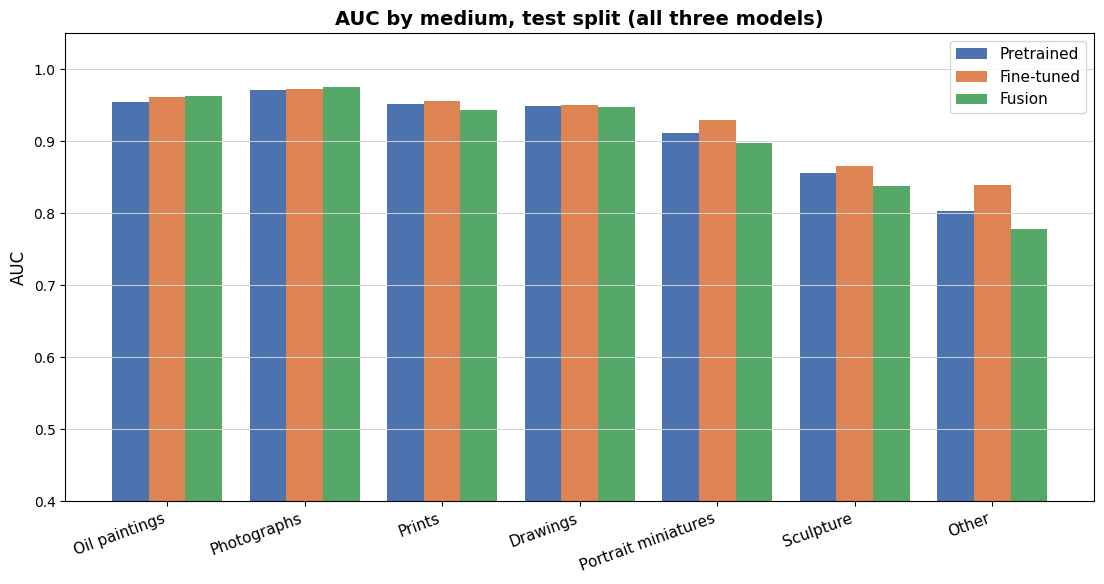

In [20]:
long_exp12 = compare_models_by_stratum(strata_pairs_test,
                                        [('Pretrained', emb_pretrained), ('Fine-tuned', emb_finetuned), ('Fusion', emb_fusion)])
for _, r in long_exp12.iterrows():
    log_scorecard('EXP12', r['Stratum'], r['Model'],
                   {'AUC': r['AUC'], 'macro_AUC': r['Macro-AUC'], 'EER': r['EER'],
                    'TAR@1%': r['TAR@1%'], 'TAR@0.1%': r['TAR@0.1%']})

display(wide_with_deltas(long_exp12, 'AUC').style.format('{:.4f}'))
display(wide_with_deltas(long_exp12, 'EER').style.format('{:.4f}'))
plot_grouped_bars(long_exp12, 'AUC', title='AUC by medium, test split (all three models)', ylim=[0.4,1.05])

### EXP13: Cross-medium genuine pairs

Reproduces EXP3 with the fusion model, compared to EXP3 and EXP8.

Model,Fine-tuned,Fusion,Pretrained,Δ Fine-tuned,Δ Fusion
Stratum,,,,,
Drawings × Photographs,0.8867,0.8349,0.8569,0.0298,-0.0220
Drawings × Prints,0.9253,0.9304,0.9301,-0.0048,0.0003
Oil paintings × Drawings,0.9358,0.9456,0.9272,0.0086,0.0184
Oil paintings × Photographs,0.9054,0.9211,0.9039,0.0015,0.0172
Oil paintings × Prints,0.9315,0.9353,0.9347,-0.0032,0.0006
Photographs × Prints,0.9472,0.9068,0.9147,0.0325,-0.0079


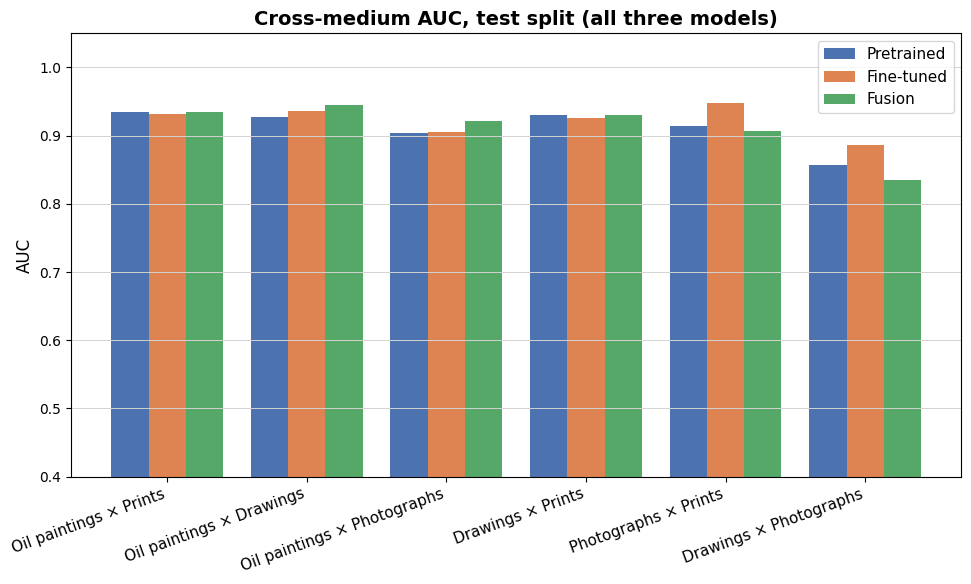

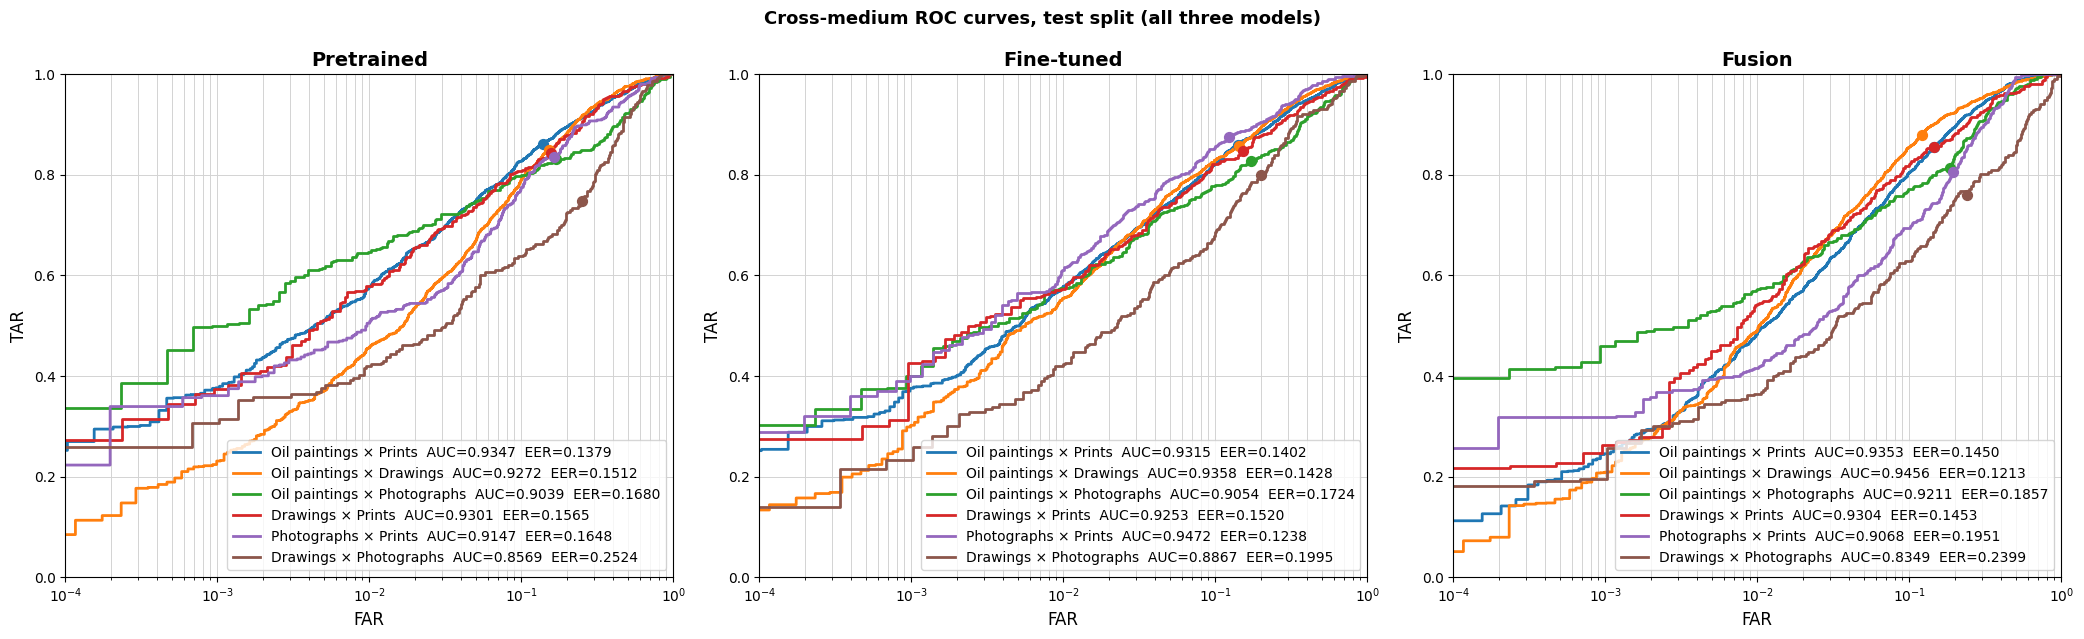

In [21]:
long_exp13 = compare_models_by_stratum(strata_pairs_cross_test,
                                        [('Pretrained', emb_pretrained), ('Fine-tuned', emb_finetuned), ('Fusion', emb_fusion)])
for _, r in long_exp13.iterrows():
    log_scorecard('EXP13', r['Stratum'], r['Model'],
                   {'AUC': r['AUC'], 'macro_AUC': r['Macro-AUC'], 'EER': r['EER'],
                    'TAR@1%': r['TAR@1%'], 'TAR@0.1%': r['TAR@0.1%']})

display(wide_with_deltas(long_exp13, 'AUC').style.format('{:.4f}'))
plot_grouped_bars(long_exp13, 'AUC', title='Cross-medium AUC, test split (all three models)', ylim=[0.4,1.05])

plot_roc_panels(strata_pairs_cross_test,
                 [('Pretrained', emb_pretrained), ('Fine-tuned', emb_finetuned), ('Fusion', emb_fusion)],
                 suptitle='Cross-medium ROC curves, test split (all three models)')

### RQ3b: Does the CLIP+LoRA fusion model reduce artist bias?

### EXP14: Artist bias and genuine pair difficulty (fusion model)

Reproduces EXP4 and EXP5 with the fusion model, on the same test-split artist-bias pairs built in EXP10 (`bias_exp10`). Compared directly to EXP4/EXP5 (full dataset) and EXP10 (fine-tuned, test split).

- **EXP14a** (↔ EXP4a, EXP10a): within- vs. cross-artist impostor scores.
- **EXP14b** (↔ EXP4b, EXP10b): the same, by medium.
- **EXP14c** (↔ EXP5, EXP10c): within- vs. cross-artist genuine-pair difficulty.

Note: the fusion embedding (1792-d, three concatenated normalized components) is not necessarily on the same cosine-similarity scale as the single-backbone 512-d embeddings — raw-mean comparisons (EXP14a/b) against EXP4a/b or EXP10a/b should be read with that in mind; the AUC/EER-based EXP14c is not affected by this and is the more directly comparable of the two.

,Model,Mean within,Mean cross,Absolute gap,Ratio
0,Pretrained,0.1418,0.0732,0.0686,1.94
1,Fine-tuned,0.0557,0.0019,0.0538,29.32
2,Fusion,0.2190,0.1032,0.1158,2.12


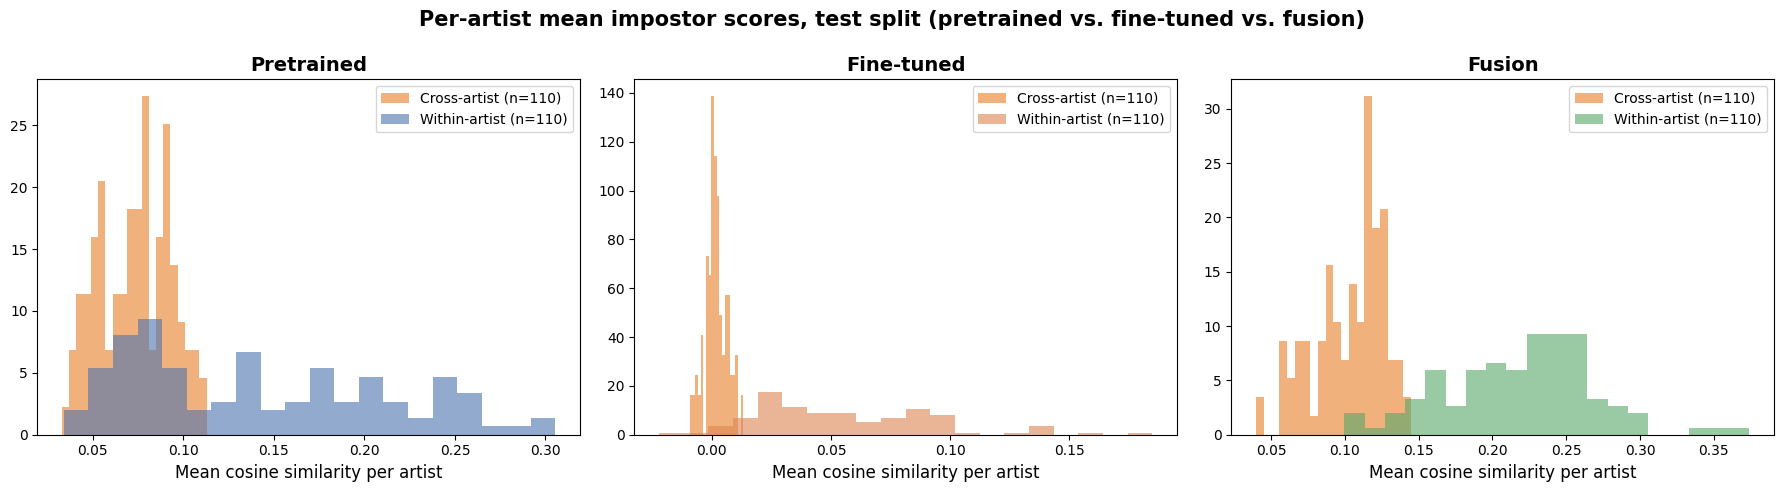

In [22]:
res_exp14a_fus = artist_bias_summary(bias_exp10, emb_fusion)

display(pd.DataFrame({
    'Model':     ['Pretrained', 'Fine-tuned', 'Fusion'],
    'Mean within': [round(float(np.mean(res_exp10a_pre['wm'])),4), round(float(np.mean(res_exp10a_ft['wm'])),4), round(float(np.mean(res_exp14a_fus['wm'])),4)],
    'Mean cross':  [round(float(np.mean(res_exp10a_pre['cm'])),4), round(float(np.mean(res_exp10a_ft['cm'])),4), round(float(np.mean(res_exp14a_fus['cm'])),4)],
}).assign(**{'Absolute gap': lambda d: (d['Mean within']-d['Mean cross']).round(4),
             'Ratio': lambda d: (d['Mean within']/d['Mean cross'].clip(lower=1e-9)).round(2)}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, [('Pretrained', res_exp10a_pre), ('Fine-tuned', res_exp10a_ft), ('Fusion', res_exp14a_fus)]):
    ax.hist(res['cm'], bins=20, density=True, alpha=0.6, color='#E87D27', label=f"Cross-artist (n={len(res['cm'])})")
    ax.hist(res['wm'], bins=20, density=True, alpha=0.6, color=MODEL_COLORS[name], label=f"Within-artist (n={len(res['wm'])})")
    ax.set_title(name); ax.set_xlabel('Mean cosine similarity per artist'); ax.legend(fontsize=10)
plt.suptitle('Per-artist mean impostor scores, test split (pretrained vs. fine-tuned vs. fusion)')
plt.tight_layout(); plt.show()

EXP14b compares WITHIN-ARTIST vs. CROSS-ARTIST IMPOSTOR scores (different sitters, i.e. does sharing
an artist inflate similarity between two different people), stratified by medium.
(Not genuine pairs — EXP14c covers within- vs. cross-artist genuine-pair difficulty.)


,Medium,Model,N artists,Mean within,Mean cross,Mean delta,p-value
0,Drawings,Pretrained,22,0.1650,0.0883,+0.0766,0.0001
1,Oil paintings,Pretrained,47,0.1717,0.0990,+0.0727,0.0000
2,Photographs,Pretrained,33,0.0690,0.0657,+0.0032,0.1216
3,Prints,Pretrained,23,0.1766,0.1184,+0.0582,0.0000
4,Drawings,Fine-tuned,22,0.0811,0.0078,+0.0733,0.0000
5,Oil paintings,Fine-tuned,47,0.0658,0.0070,+0.0588,0.0000
6,Photographs,Fine-tuned,33,0.0267,0.0182,+0.0086,0.0021
7,Prints,Fine-tuned,23,0.0758,0.0220,+0.0537,0.0000
8,Drawings,Fusion,22,0.2162,0.1201,+0.0962,0.0000
9,Oil paintings,Fusion,47,0.2177,0.1037,+0.1141,0.0000


Compare to EXP4b (Pretrained, full dataset) and EXP10b (Pretrained/Fine-tuned, test split).


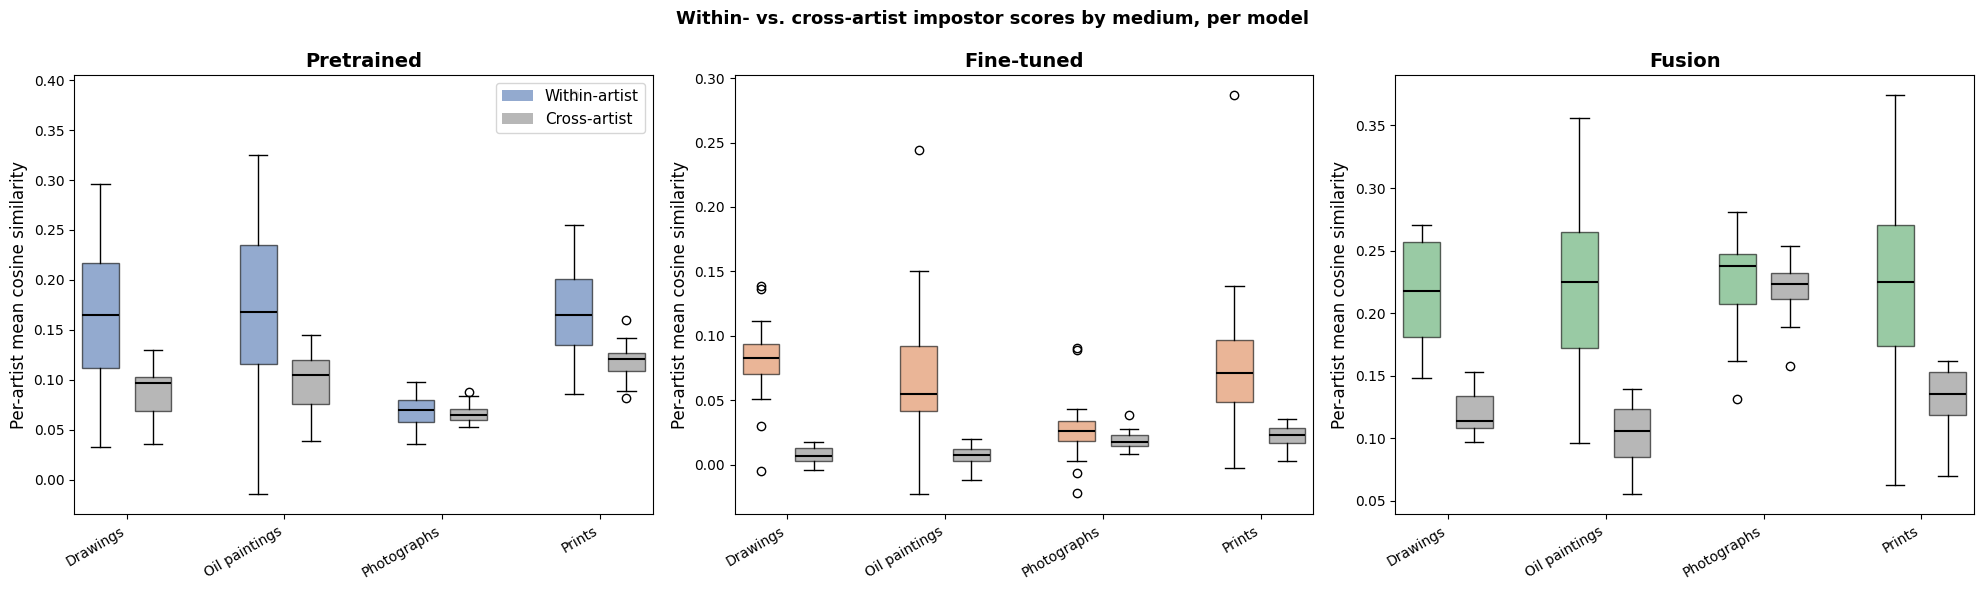

In [23]:
df_exp14b_fus, medium_data_14b_fus = medium_bias_table(within_tagged_exp10, cross_tagged_med_exp10, emb_fusion)
df_exp14b_fus['Model'] = 'Fusion'
df_exp14b = pd.concat([df_exp10b, df_exp14b_fus], ignore_index=True)

print('EXP14b compares WITHIN-ARTIST vs. CROSS-ARTIST IMPOSTOR scores (different sitters, i.e. does sharing')
print('an artist inflate similarity between two different people), stratified by medium.')
print('(Not genuine pairs — EXP14c covers within- vs. cross-artist genuine-pair difficulty.)')

display(df_exp14b[['Medium','Model','N artists','Mean within','Mean cross','Mean delta','p-value']]
        .style.format({'Mean within':'{:.4f}','Mean cross':'{:.4f}','Mean delta':'{:+.4f}','p-value':'{:.4f}','N artists':'{:,}'}))
print('Compare to EXP4b (Pretrained, full dataset) and EXP10b (Pretrained/Fine-tuned, test split).')

# Per-medium within- vs. cross-artist boxplot, one panel per model (Pretrained/Fine-tuned recomputed here — cheap, no model inference)
_, medium_data_14b_pre = medium_bias_table(within_tagged_exp10, cross_tagged_med_exp10, emb_pretrained)
_, medium_data_14b_ft  = medium_bias_table(within_tagged_exp10, cross_tagged_med_exp10, emb_finetuned)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, medium_data) in zip(axes, [('Pretrained', medium_data_14b_pre),
                                           ('Fine-tuned', medium_data_14b_ft),
                                           ('Fusion',     medium_data_14b_fus)]):
    media_list = list(medium_data.keys())
    pos_w, pos_c, box_w, box_c = [], [], [], []
    for i, medium in enumerate(media_list):
        pos_w.append(i * 3 + 0.75); pos_c.append(i * 3 + 1.75)
        box_w.append(medium_data[medium]['wm']); box_c.append(medium_data[medium]['cm'])
    ax.boxplot(box_w, positions=pos_w, widths=0.7, patch_artist=True,
               boxprops=dict(facecolor=MODEL_COLORS[name], alpha=0.6), medianprops=dict(color='black', lw=1.5))
    ax.boxplot(box_c, positions=pos_c, widths=0.7, patch_artist=True,
               boxprops=dict(facecolor='#888888', alpha=0.6), medianprops=dict(color='black', lw=1.5))
    ax.set_xticks([i * 3 + 1.25 for i in range(len(media_list))])
    ax.set_xticklabels(media_list, rotation=30, ha='right', fontsize=10)
    ax.set_title(name)
    ax.set_ylabel('Per-artist mean cosine similarity')
axes[0].legend([Patch(facecolor=MODEL_COLORS['Pretrained'], alpha=0.6), Patch(facecolor='#888888', alpha=0.6)],
               ['Within-artist', 'Cross-artist'], fontsize=11, loc='upper right')
plt.suptitle('Within- vs. cross-artist impostor scores by medium, per model', fontsize=13)
plt.tight_layout(); plt.show()

,Model,AUC within,AUC cross,Gap (within-cross),EER within,EER cross
0,Pretrained,0.9612,0.9362,+0.0250,0.1039,0.1375
1,Fine-tuned,0.9651,0.9400,+0.0251,0.0940,0.1305
2,Fusion,0.9668,0.9327,+0.0341,0.0954,0.1488


Compare to EXP5 (Pretrained, full dataset) and EXP10c (Pretrained/Fine-tuned, test split).


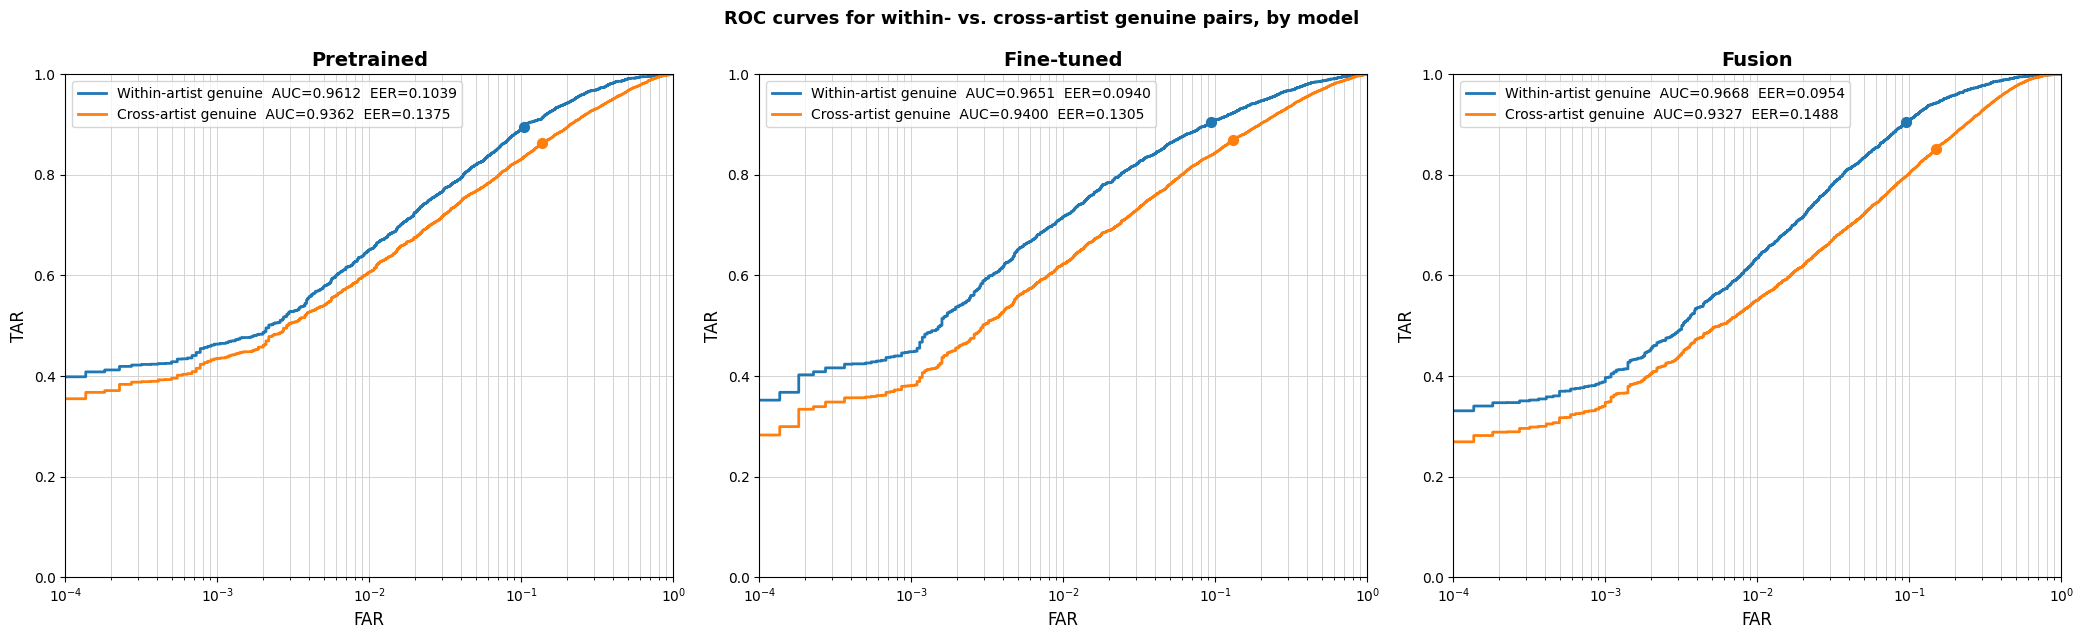

In [24]:
sc_w, lb_w, sa_w, sb_w = score_pairs(within_genuine_exp10 + impostor_pairs_exp10, emb_fusion)
sc_c, lb_c, sa_c, sb_c = score_pairs(cross_genuine_exp10  + impostor_pairs_exp10, emb_fusion)
m_w_fus = compute_metrics(sc_w, lb_w, sa_w, sb_w)
m_c_fus = compute_metrics(sc_c, lb_c, sa_c, sb_c)
log_scorecard('EXP14c', 'Within-artist genuine', 'Fusion', m_w_fus)
log_scorecard('EXP14c', 'Cross-artist genuine',  'Fusion', m_c_fus)

rows_exp14c = rows_exp10c + [{'Model': 'Fusion', 'AUC within': m_w_fus['AUC'], 'AUC cross': m_c_fus['AUC'],
                               'Gap (within-cross)': round(m_w_fus['AUC']-m_c_fus['AUC'],4),
                               'EER within': m_w_fus['EER'], 'EER cross': m_c_fus['EER']}]
display(pd.DataFrame(rows_exp14c).style.format({'AUC within':'{:.4f}','AUC cross':'{:.4f}',
                                                  'Gap (within-cross)':'{:+.4f}','EER within':'{:.4f}','EER cross':'{:.4f}'}))
print('Compare to EXP5 (Pretrained, full dataset) and EXP10c (Pretrained/Fine-tuned, test split).')

# ROC panels: one per model, within-artist genuine vs. cross-artist genuine
strata_pairs_14c = {
    'Within-artist genuine': within_genuine_exp10 + impostor_pairs_exp10,
    'Cross-artist genuine':  cross_genuine_exp10  + impostor_pairs_exp10,
}
plot_roc_panels(strata_pairs_14c,
                 [('Pretrained', emb_pretrained), ('Fine-tuned', emb_finetuned), ('Fusion', emb_fusion)],
                 suptitle='ROC curves for within- vs. cross-artist genuine pairs, by model')

---
# Summary scorecard

Every headline number logged across EXP1-EXP14, in one table.

In [25]:
scorecard_df = pd.DataFrame(SCORECARD)
display(scorecard_df.style.format({'AUC':'{:.4f}','Macro-AUC':'{:.4f}','EER':'{:.4f}','TAR@1%':'{:.4f}','TAR@0.1%':'{:.4f}'}))
# scorecard_df.to_csv('evaluation2_scorecard.csv', index=False)

,Experiment,Stratum,Model,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%
0,EXP1,Full dataset,Pretrained,0.9383,0.9513,0.1363,0.5944,0.3836
1,EXP2,Oil paintings,Pretrained,0.9544,0.9579,0.1144,0.6551,0.4474
2,EXP2,Photographs,Pretrained,0.9790,0.9724,0.0613,0.8916,0.8201
3,EXP2,Prints,Pretrained,0.9121,0.9615,0.1669,0.4916,0.2909
4,EXP2,Drawings,Pretrained,0.9273,0.9254,0.1484,0.5449,0.3290
5,EXP2,Portrait miniatures,Pretrained,0.8981,0.9333,0.1890,0.5010,0.3372
6,EXP2,Sculpture,Pretrained,0.8484,0.9085,0.2322,0.3153,0.1703
7,EXP2,Other,Pretrained,0.8127,0.7940,0.2581,0.0000,0.0000
8,EXP3,Oil paintings × Prints,Pretrained,0.9295,0.9397,0.1465,0.5360,0.2980
9,EXP3,Oil paintings × Drawings,Pretrained,0.8941,0.9181,0.1903,0.4530,0.2702
